# Decnovolution analysis

### Step 0: Import needed classes and set paths

In [ ]:
from methyldl.modelling.methylbert import MethylVocab, MethylBertFinetuneDataset
from methyldl.data.genome import generate_kmer_str_with_overlap
from methyldl.data import CELL_TYPE_MATCH_DICT as cell_type_match_dict
from methyldl.data.bam_processing import *
from methyldl.data.preprocessing import *
from methyldl.data.pseudo_bulk_generation import *
from methyldl.data.genome import *
from methyldl.deconvolution.uxm import *
from methyldl.inference.prediction_aggregation import *
from methyldl.visualization.kde_plotting import *
from methyldl.visualization.bland_altman_analysis import *
from methyldl.visualization.methylation_plotting import *
from methyldl.visualization.predictions_plotting import *
from methyldl.deconvolution.training import *
from methyldl.deconvolution.flatten_mlp_deconvolver import *
from methyldl.deconvolution.dmr_attention_deconvolver import *
from methyldl.deconvolution.diagonal_aware_deconvolver import *
from methyldl.deconvolution.cnn_deconvolver import *
from methyldl.modelling.methylbert import MethylBert, default_methylbert_config

/home/luna.kuleuven.be/u0169940/.cache/pypoetry/virtualenvs/methyldl-GStZGe-R-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
seq_length = 150
reads_data_path = "/home/luna.kuleuven.be/u0169940/Data/Loyfer/TrainingDataWithRejection_hg38_mincpg_4_minlen_10/"
dmr_label_column = "dmr_ctype_label"
mincpg_pointer = reads_data_path.find("mincpg_")
classifier_model_path = f"../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_{dmr_label_column}_{reads_data_path[mincpg_pointer:]}"
mincpg = int(reads_data_path[mincpg_pointer + 7 : mincpg_pointer + 8])
model_checkpoint = [x for x in os.listdir(classifier_model_path) if "checkpoint" in x][
    0
]
fine_tuned_model_path = os.path.join(
    classifier_model_path, model_checkpoint, "model.safetensors"
)

In [9]:
dmrs = pd.DataFrame(
    pd.concat(
        [
            pd.read_parquet(reads_data_path + f"/{split}.parquet")
            for split in ["train", "valid", "test"]
        ]
    )[dmr_label_column].unique()
)
dmrs.columns = [dmr_label_column]

In [4]:
def prepare_methylbert_list(
    data_path,
    split,
    dmr_label_column,
    seq_length=500,
    dna_column="seq",
    methylation_column="pattern",
):
    data = pd.read_parquet(data_path + f"/{split}.parquet")
    # data = data.merge(dmrs, on=["dmr_label"])
    data_list = [
        ["dna_seq", "methyl_seq", "dmr_ctype", "dmr_label", "ctype", "original_label"]
    ]
    for i, row in data.iterrows():
        dna = generate_kmer_str_with_overlap(row[dna_column][: (seq_length + 2)])
        methyl = row[methylation_column][1:-1][:seq_length]
        if not len(dna) or not len(methyl):
            # print(row["input_ids"])
            # print(row["read_name"])
            continue
        label = row["label"]
        o_label = row["original_label"]
        dmr_label = row[dmr_label_column]
        dmr_ctype = row["dmr_ctype_label"]
        data_list.append([dna, methyl, dmr_ctype, dmr_label, label, o_label])
    return data_list

In [5]:
train, valid = [
    prepare_methylbert_list(
        reads_data_path,
        split=x,
        dmr_label_column=dmr_label_column,
        seq_length=seq_length,
    )
    for x in ["train", "valid"]
]
train_dataset, valid_dataset = [
    MethylBertFinetuneDataset(
        data_source=x,
        vocab=MethylVocab(k=3),
        seq_len=seq_length,
        lazy_tokenization=True,
    )
    for x in [train, valid]
]

Building Vocab
Total number of sequences: 199844
Using lazy tokenization (on-the-fly processing)
Building Vocab
Total number of sequences: 95063
Using lazy tokenization (on-the-fly processing)


In [5]:
from collections import OrderedDict

In [6]:
rrms_config = OrderedDict(
    [
        ("lr", 0.0004),
        ("beta", (0.9, 0.98)),
        ("weight_decay", 0.1),
        ("warmup_step", 100),
        ("eps", 1e-6),
        ("with_cuda", True),
        ("log_freq", 200),
        ("eval_freq", 200),
        ("n_hidden", None),
        ("decrease_steps", 200),
        ("eval", False),
        ("amp", True),
        ("gradient_accumulation_steps", 1),
        ("max_grad_norm", 1.0),
        ("save_freq", None),
        ("loss", "ce"),
        ("adam_beta1", 0.9),
        ("adam_beta2", 0.98),
        ("seed", 950410),
    ]
)

In [10]:
model_instance = MethylBert(
    custom_config=rrms_config,
    foundation_model_path="hanyangii/methylbert_hg19_12l",
    num_labels=40,
    num_dmr_labels=max(dmrs[dmr_label_column]) + 1,
    fine_tuned_model_path=fine_tuned_model_path,
    classifier_implementation="dmr_attention_based",
)

Loading MethylBertEmbeddedDMR with dmr_attention_based classifier from fine-tuned path: ../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_4_minlen_10/checkpoint-1650/model.safetensors
Cross Entropy loss assigned (multi-class)
Using attention-based classifier with DMR context


In [11]:
test = prepare_methylbert_list(
    reads_data_path,
    split="test",
    dmr_label_column=dmr_label_column,
    seq_length=seq_length,
)
test_dataset = MethylBertFinetuneDataset(
    data_source=test, vocab=MethylVocab(k=3), seq_len=seq_length, lazy_tokenization=True
)

Building Vocab
Total number of sequences: 4445834
Using lazy tokenization (on-the-fly processing)


In [ ]:
# with open("../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label/test_finetune_dataset.pkl","rb") as f:
#     test_dataset = pickle.load(f)

In [9]:
with open(
    "../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_label_mincpg_3_minlen_10/predictions_test.pkl",
    "rb",
) as f:
    res = pickle.load(f)

In [ ]:
# res = model_instance.predict(test_dataset, batch_size = 2200)

OUTPUT DIR IS: tmp_trainer


/home/luna.kuleuven.be/u0169940/Repos/methyldl/methyldl/modelling/methylbert.py:581: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (0) is identical to the `bos_token_id` (0), `eos_token_id` (None), or the `sep_token_id` (None), and your input is not padded.


In [ ]:
# with open("../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_label_mincpg_4_minlen_10/predictions_test.pkl", "wb") as f:
#     pickle.dump(res,f)

In [10]:
predictions = res[0].argmax(axis=1)
labels = res[1]
confidence = res[0].max(axis=1)

In [39]:
all_data = []
for split in ["train", "valid", "test"]:
    x = pd.read_parquet(reads_data_path + f"/{split}.parquet")
    x["split"] = split
    all_data.append(x)

In [40]:
all_data = pd.concat(all_data)

In [13]:
all_data["methylated_CpGs"] = all_data["pattern"].apply(lambda x: x.count("1"))
all_data["unmethylated_CpGs"] = all_data["pattern"].apply(lambda x: x.count("0"))
all_data["methylation_level"] = all_data["methylated_CpGs"] / (
    all_data["methylated_CpGs"] + all_data["unmethylated_CpGs"]
)

In [ ]:
# all_data["methylated_CpGs"] =  all_data["original_methyl"].apply(lambda x: x.count("C"))
# all_data["unmethylated_CpGs"] = all_data["original_methyl"].apply(lambda x: x.count("T"))
# all_data["methylation_level"] = all_data["methylated_CpGs"] / (all_data["methylated_CpGs"]+ all_data["unmethylated_CpGs"])

In [14]:
all_data["total_methylated_labels"] = (
    all_data["methylated_CpGs"] + all_data["unmethylated_CpGs"]
)

In [41]:
labels_dict = {
    int(value["dmr_ctype_label"]): key
    for (key, value) in all_data[["dmr_ctype_label", "dmr_ctype"]]
    .groupby("dmr_ctype")
    .mean()
    .to_dict(orient="index")
    .items()
}

In [ ]:
# split_metadata = all_data[["label", "file","split"]].groupby(["label", "file", "split"]).count().reset_index().groupby(["label", "split"]).agg({'file':lambda x: list(x)}).reset_index()
# split_metadata["n_files"] = split_metadata["file"].apply(len)
# split_metadata["n_files"] = split_metadata["file"].apply(len)

In [ ]:
# # Convert file lists to sets for faster intersection operations
# split_metadata['file_set'] = split_metadata['file'].apply(set)

# # Initialize the intersection columns
# split_metadata['test_intersect'] = 0
# split_metadata['train_intersect'] = 0
# split_metadata['valid_intersect'] = 0

# # Calculate intersections for each row
# for idx, row in split_metadata.iterrows():
#     current_label = row['label']
#     current_split = row['split']
#     current_files = row['file_set']

#     # For each split type
#     for split_type in ['test', 'train', 'valid']:
#         # Skip if it's the same split as current row (self value = 0)
#         if split_type == current_split:
#             continue

#         # Find all rows with same label and target split
#         mask = (split_metadata['label'] == current_label) & (split_metadata['split'] == split_type)
#         target_rows = split_metadata[mask]

#         # Calculate total intersection count across all matching rows
#         total_intersection = 0
#         for _, target_row in target_rows.iterrows():
#             intersection_count = len(current_files & target_row['file_set'])
#             total_intersection += intersection_count

#         # Set the appropriate column
#         split_metadata.at[idx, f'{split_type}_intersect'] = total_intersection

# # Drop the temporary file_set column
# split_metadata = split_metadata.drop('file_set', axis=1)

In [ ]:
# split_metadata["intersect_rate"] = [max(x[1][4],x[1][5], x[1][6])for x in split_metadata.iterrows()]/split_metadata["n_files"]

List of files for which train/test/valid are derrived from overlaping files

In [ ]:
# split_metadata[split_metadata["intersect_rate"]>0]

### Loyfer Analysis

In [16]:
res_attention = res

In [17]:
predictions = np.argmax(res_attention[0], 1)
labels = res_attention[1]
confidence = res_attention[0].max(axis=1)

In [18]:
test_data = deepcopy(all_data[all_data["split"] == "test"])
test_data["prediction"] = predictions
test_data["confidence"] = confidence
labels_dict = {
    int(value["dmr_ctype_label"]): key
    for (key, value) in all_data[["dmr_ctype_label", "dmr_ctype"]]
    .groupby("dmr_ctype")
    .mean()
    .to_dict(orient="index")
    .items()
}
labels_list = [labels_dict[i] for i in range(39)]
labels_list.append("Rejected")

In [26]:
# Set Matplotlib styling
plt.rcParams.update(
    {
        "font.size": 10,
        "axes.facecolor": "white",
        "axes.edgecolor": "black",
        "grid.color": "lightgray",
        "grid.linestyle": "-",
    }
)

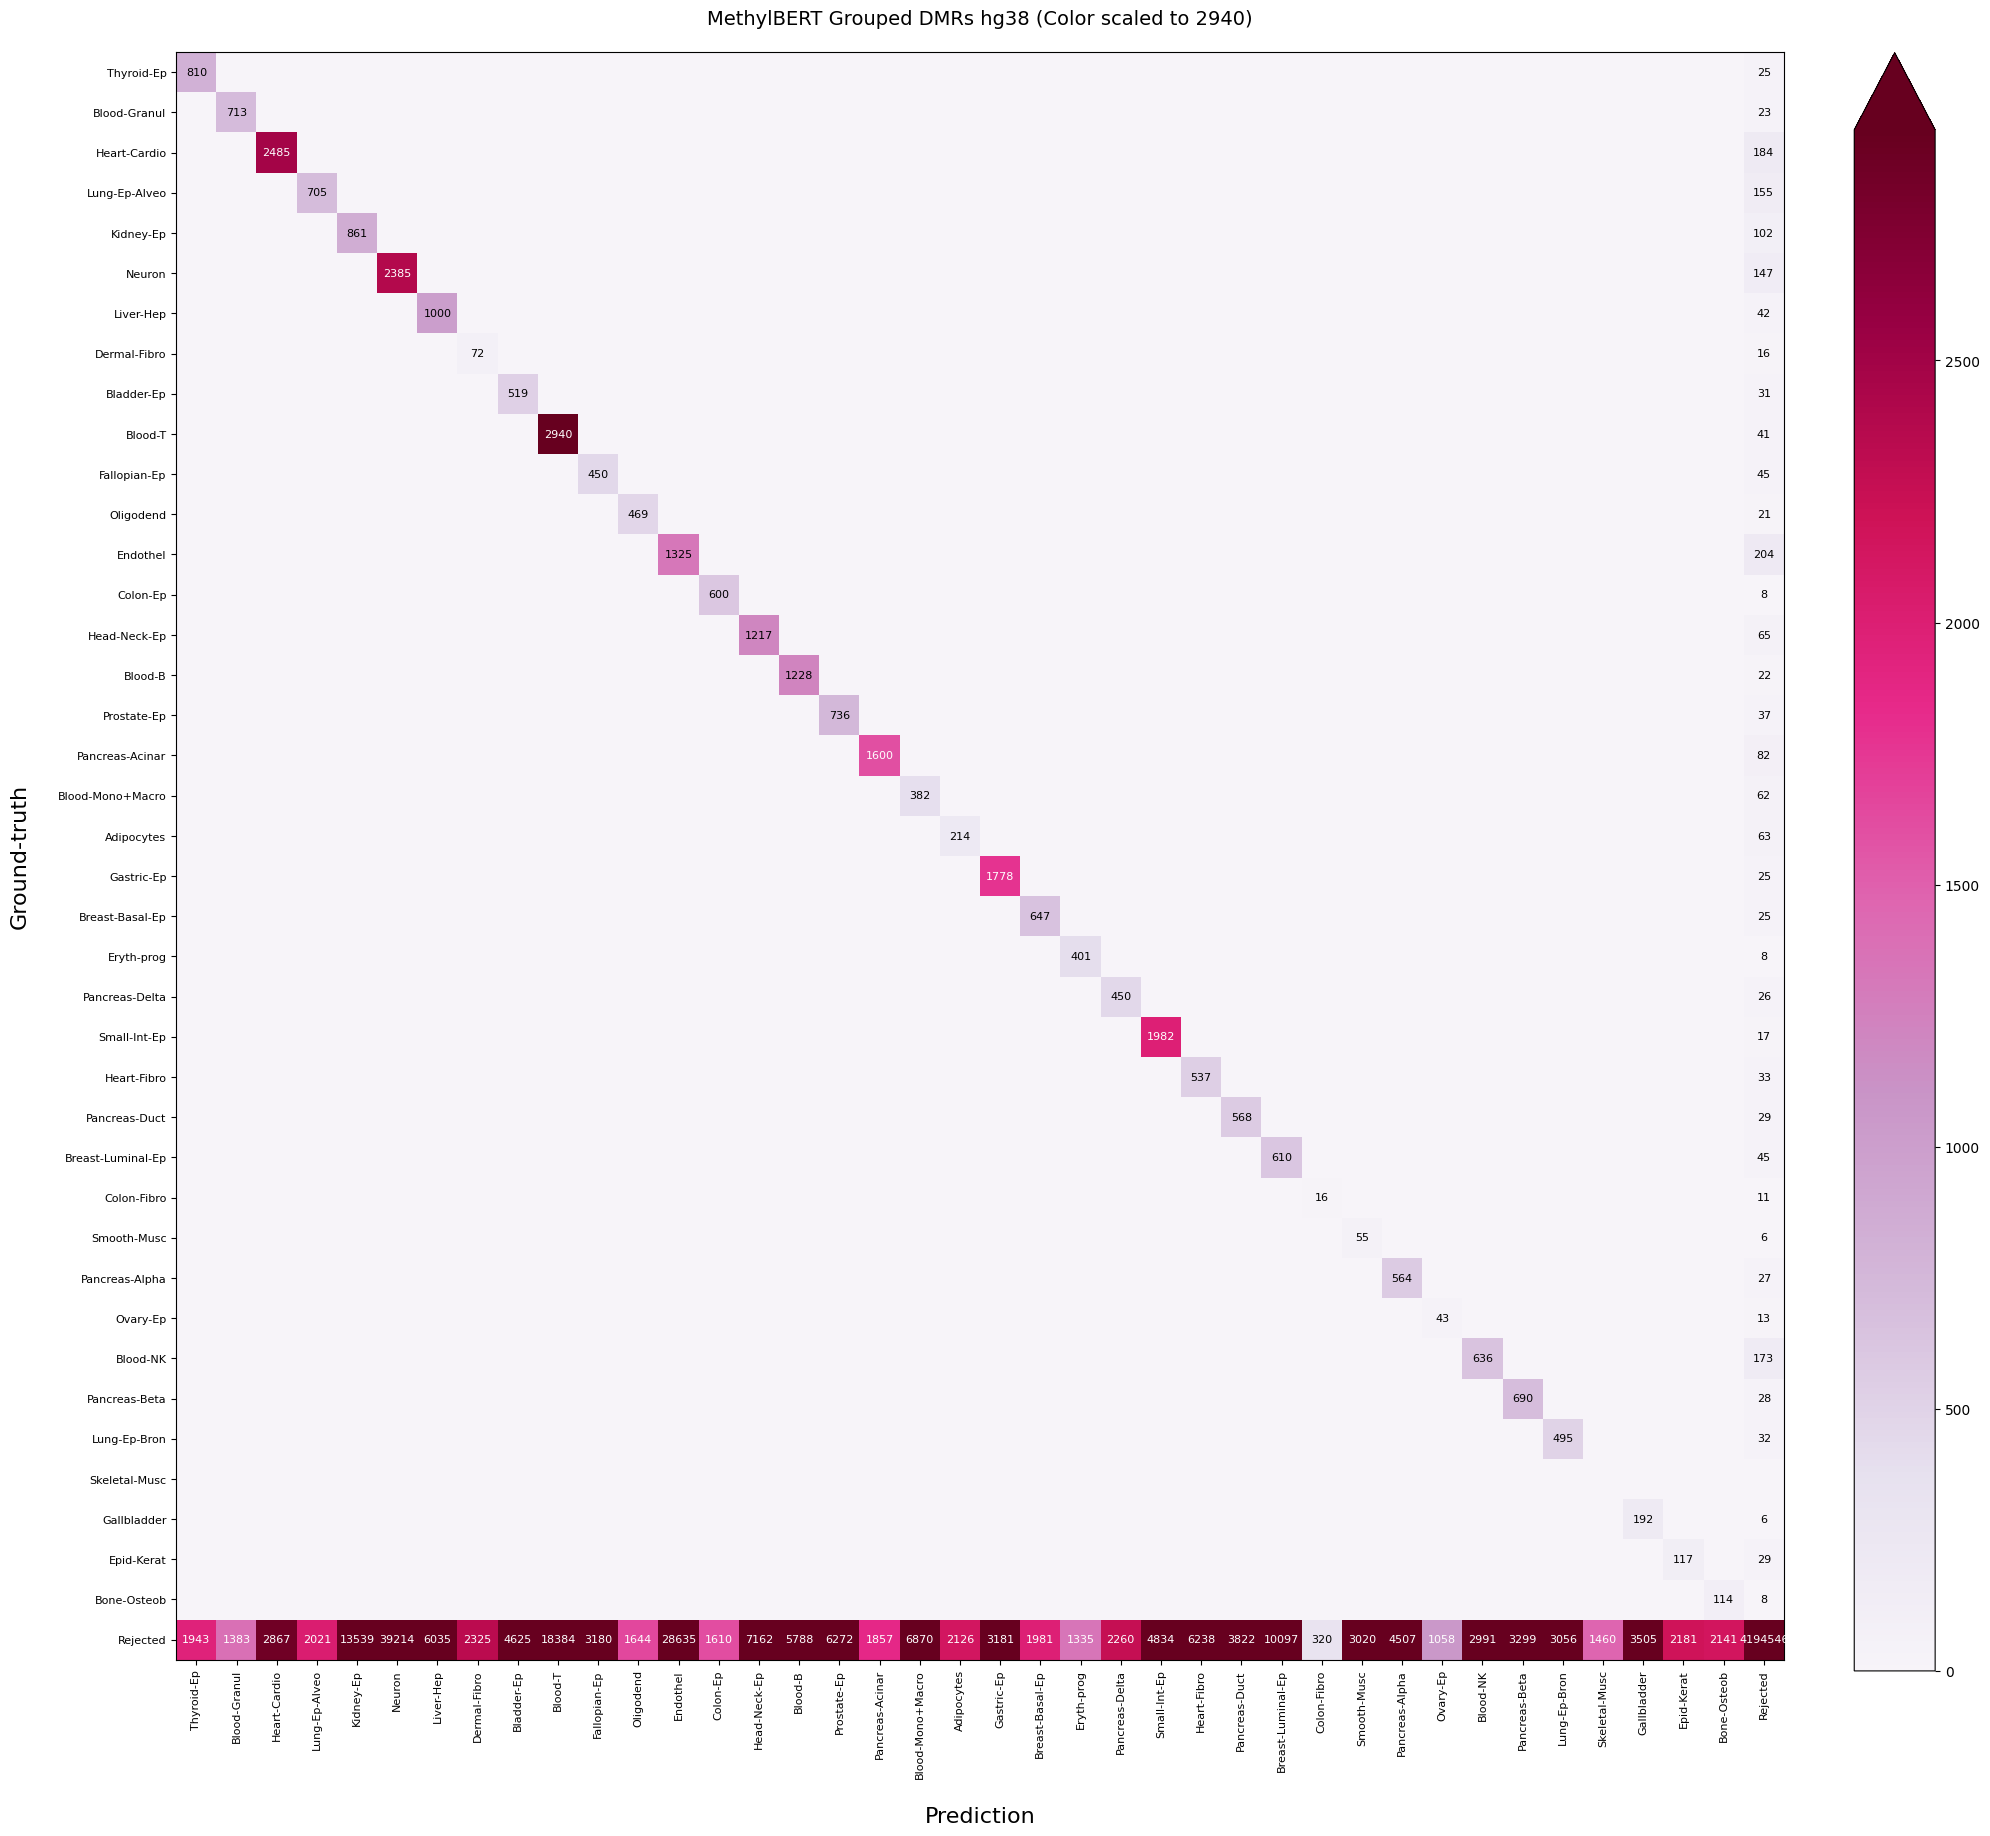

In [27]:
plot_confusion_matrix_for_target_confidence(
    predictions,
    confidence,
    target_confidence=0.5,
    labels=labels,
    labels_list=labels_list,
    title="MethylBERT Grouped DMRs hg38",
)

In [ ]:
# original_labels = np.array([int(test_dataset.raw_lines[i].split("\t")[5]) for i in range(test_size)])
# reference_labels = np.array([int(test_dataset.raw_lines[i].split("\t")[4]) for i in range(test_size)])

##### Box-plots of different predicted groups methylation levels
1. Correctly predicted
2. Incorrectly rejected
3. Incorrectly predicted 
4. Correctly rejected

In [23]:
target_confidence = 0.984
test_data["prediction"] = np.array(
    [int(x) if y > target_confidence else 39 for (x, y) in zip(predictions, confidence)]
)

Sample sizes:
1. Correctly predicted (label == prediction, label != 39): 22902
2. Incorrectly rejected (label != 39, prediction == 39): 9620
3. Incorrectly predicted (label == 39, prediction != 39): 18528
4. Correctly rejected (label == prediction == 39): 4394784


Summary Statistics:
--------------------------------------------------------------------------------

Correctly Predicted:
  Count: 22902
  Mean: 0.0294
  Median: 0.0000
  Std: 0.0761
  Min: 0.0000
  Max: 0.7500
  Q1 (25%): 0.0000
  Q3 (75%): 0.0000

Incorrectly Rejected:
  Count: 9620
  Mean: 0.3168
  Median: 0.2500
  Std: 0.3412
  Min: 0.0000
  Max: 1.0000
  Q1 (25%): 0.0000
  Q3 (75%): 0.5000

Incorrectly Predicted:
  Count: 18528
  Mean: 0.1162
  Median: 0.0000
  Std: 0.1523
  Min: 0.0000
  Max: 1.0000
  Q1 (25%): 0.0000
  Q3 (75%): 0.2500

Correctly Rejected:
  Count: 4394784
  Mean: 0.9274
  Median: 1.0000
  Std: 0.1369
  Min: 0.0000
  Max: 1.0000
  Q1 (25%): 0.8571
  Q3 (75%): 1.0000


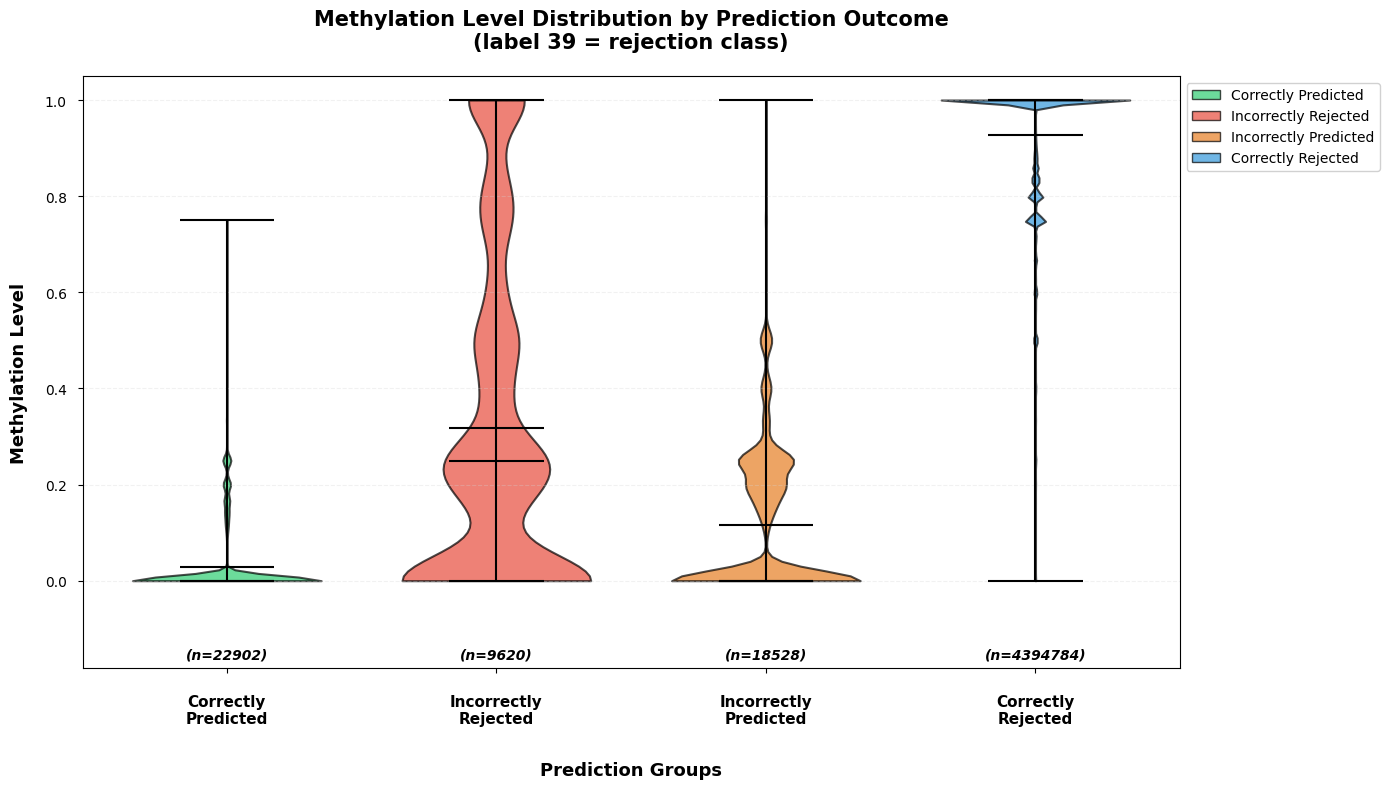

(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'Methylation Level Distribution by Prediction Outcome\n(label 39 = rejection class)'}, xlabel='Prediction Groups', ylabel='Methylation Level'>)

In [65]:
create_methylation_violinplots(test_data)

##### Box-plot for naive classifier that is tresholding based on methylation status
Assignes label equal to dmr_label whenever read is hypomethylated; otherwise rejects:

In [51]:
test_data["prediction"] = np.array(
    [
        x if y < 0.1 else 39
        for (x, y) in zip(test_data["dmr_ctype_label"], test_data["methylation_level"])
    ]
)

Sample sizes:
1. Correctly predicted (label == prediction, label != 39): 23195
2. Incorrectly rejected (label != 39, prediction == 39): 9327
3. Incorrectly predicted (label == 39, prediction != 39): 18572
4. Correctly rejected (label == prediction == 39): 4394740


Summary Statistics:
--------------------------------------------------------------------------------

Correctly Predicted:
  Count: 23195
  Mean: 0.0003
  Median: 0.0000
  Std: 0.0052
  Min: 0.0000
  Max: 0.0909
  Q1 (25%): 0.0000
  Q3 (75%): 0.0000

Incorrectly Rejected:
  Count: 9327
  Mean: 0.3982
  Median: 0.2500
  Std: 0.2852
  Min: 0.1000
  Max: 1.0000
  Q1 (25%): 0.2000
  Q3 (75%): 0.5000

Incorrectly Predicted:
  Count: 18572
  Mean: 0.0002
  Median: 0.0000
  Std: 0.0042
  Min: 0.0000
  Max: 0.0909
  Q1 (25%): 0.0000
  Q3 (75%): 0.0000

Correctly Rejected:
  Count: 4394740
  Mean: 0.9279
  Median: 1.0000
  Std: 0.1341
  Min: 0.1000
  Max: 1.0000
  Q1 (25%): 0.8571
  Q3 (75%): 1.0000


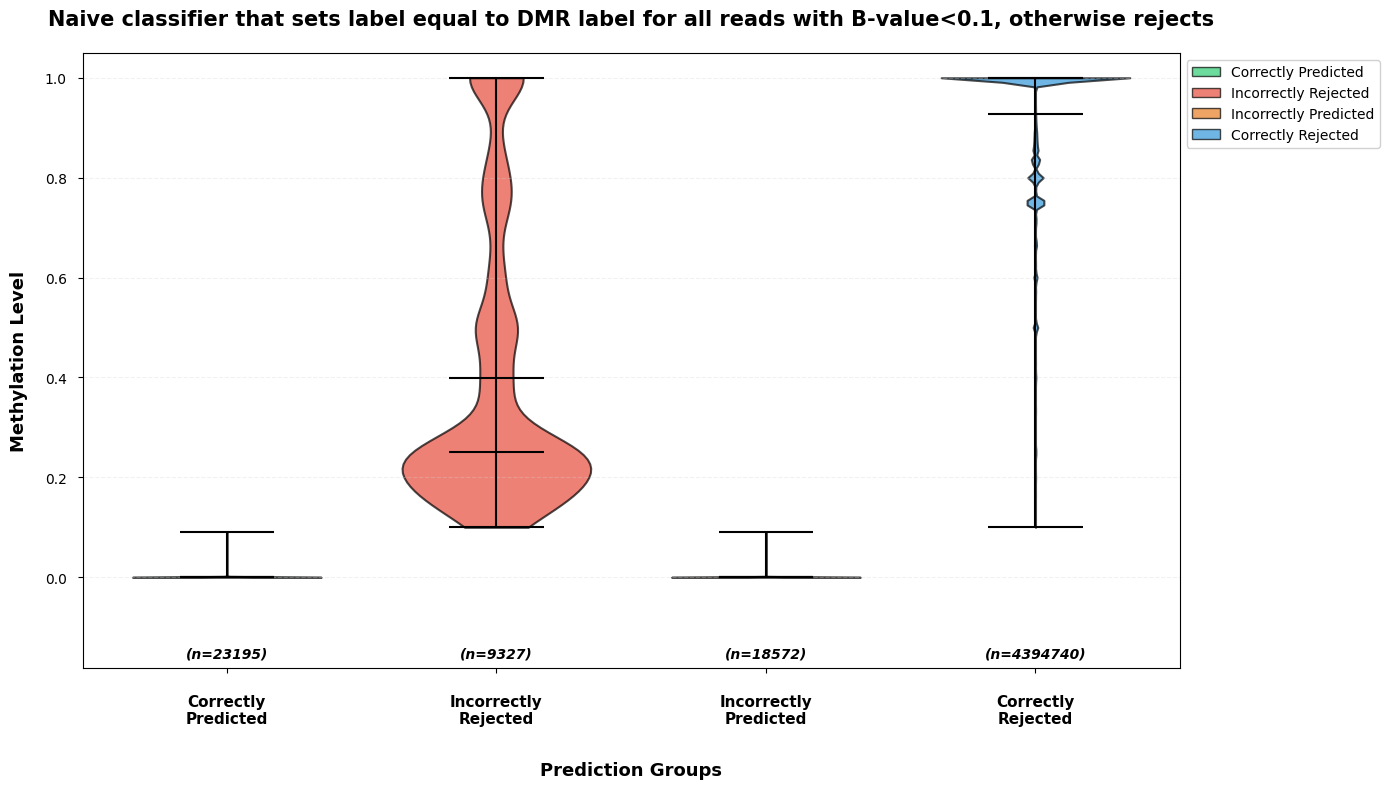

(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'Naive classifier that sets label equal to DMR label for all reads with B-value<0.1, otherwise rejects'}, xlabel='Prediction Groups', ylabel='Methylation Level'>)

In [52]:
create_methylation_violinplots(
    test_data,
    title="Naive classifier that sets label equal to DMR label for all reads with B-value<0.1, otherwise rejects",
)

### Aggregating predictions

In [19]:
res_attention_pd = pd.DataFrame(
    res_attention[0], columns=["prediction_" + str(x) for x in range(40)]
)
test_data = pd.concat([test_data, res_attention_pd], axis=1)

In [20]:
selected_columns = ["prediction_" + str(x) for x in range(40)]
selected_columns.extend(["dmr_label", "dmr_ctype", "file", "label", "orginal_label"])

In [21]:
test_data["total_marked_cpgs"] = (
    test_data["methylated_CpGs"] + test_data["unmethylated_CpGs"]
)

#### Individual DMRs

In [ ]:
aggregated_predictions = aggregate_predictions_by_dmr(test_data)

In [ ]:
final_predictions = get_final_prediction(aggregated_predictions)

In [ ]:
final_predictions_avg = final_predictions[
    [
        "label",
        "original_label",
        "final_prediction_avg",
        "final_confidence_avg",
        "methylation_level_avg",
    ]
]
final_predictions_avg.columns = [
    "label",
    "original_label",
    "prediction",
    "confidence",
    "methylation_level",
]

final_predictions = final_predictions[
    [
        "label",
        "original_label",
        "final_prediction",
        "final_confidence",
        "methylation_level_wavg",
    ]
]
final_predictions_wavg.columns = [
    "label",
    "original_label",
    "prediction",
    "confidence",
    "methylation_level",
]

In [ ]:
create_methylation_violinplots(
    final_predictions_avg, title="Averaging of predictions by DMR and file of origin"
)

In [ ]:
create_methylation_violinplots(
    final_predictions_wavg,
    title="CpG Weighted averaging of predictions by DMR and file of origin",
)

In [ ]:
final_predictions_wavg_confident = deepcopy(final_predictions_wavg)
target_confidence = 0.8
final_predictions_wavg_confident["prediction"] = np.array(
    [
        int(x) if y > target_confidence else 39
        for (x, y) in zip(
            final_predictions_wavg["prediction"], final_predictions_wavg["confidence"]
        )
    ]
)

In [ ]:
create_methylation_violinplots(
    final_predictions_wavg_confident,
    title=f"CpG Weighted averaging of predictions by DMR and file of origin with minimum confidence: {target_confidence}",
)

#### Cell-specific DMRs versus all other DMRs

In [22]:
test_data["is_cell_informative_region"] = (
    test_data["original_label"] == test_data["dmr_ctype_label"]
)

In [ ]:
aggregated_predictions_by_file = aggregate_predictions_by_dmr(
    test_data, group_cols=["file", "original_label", "is_cell_informative_region"]
)

In [ ]:
final_predictions_by_file = get_final_prediction(aggregated_predictions_by_file)

In [ ]:
final_predictions_by_file = final_predictions_by_file[
    [
        "label",
        "original_label",
        "final_prediction_wavg",
        "final_confidence_wavg",
        "methylation_level_wavg",
    ]
]
final_predictions_by_file.columns = [
    "label",
    "original_label",
    "prediction",
    "confidence",
    "methylation_level",
]
labels, confident_predictions = (
    final_predictions_by_file["label"],
    final_predictions_by_file["prediction"],
)

#### Cell-specific DMR regions aggregation

In [31]:
aggregated_predictions_by_groupped_dmrs = aggregate_predictions_by_dmr(
    test_data,
    group_cols=[
        "file",
        "original_label",
        "is_cell_informative_region",
        "dmr_ctype_label",
    ],
)

In [32]:
final_predictions_by_dmr_groups = get_final_prediction(
    aggregated_predictions_by_groupped_dmrs
)

In [33]:
agg_method = "avg"

In [34]:
final_predictions_by_dmr_groups = final_predictions_by_dmr_groups[
    [
        "label",
        "original_label",
        f"final_prediction_{agg_method}",
        f"final_confidence_{agg_method}",
        "methylation_level_wavg",
        "dmr_ctype_label",
        "is_cell_informative_region",
        "file",
        "n_reads",
        "total_weight",
    ]
]
final_predictions_by_dmr_groups.columns = [
    "label",
    "original_label",
    "prediction",
    "confidence",
    "methylation_level",
    "dmr_ctype_label",
    "is_cell_informative_region",
    "file",
    "n_reads",
    "total_weight",
]
labels, confident_predictions = (
    final_predictions_by_dmr_groups["label"],
    final_predictions_by_dmr_groups["prediction"],
)

In [35]:
final_predictions_by_dmr_groups_agg = final_predictions_by_dmr_groups.groupby(
    ["file", "original_label", "label"]
).aggregate(
    {
        "prediction": lambda x: list(x),
        "confidence": lambda x: list(x),
        "dmr_ctype_label": lambda x: list(x),
    }
)

In [36]:
final_predictions_by_dmr_groups_agg.reset_index(inplace=True)

In [37]:
mask = final_predictions_by_dmr_groups_agg["prediction"].apply(
    lambda x: [element != 39 for element in x]
)

In [38]:
final_predictions_by_dmr_groups_agg["predictions_without_rejection"] = [
    np.array(x)[np.array(y)]
    for (x, y) in zip(final_predictions_by_dmr_groups_agg["prediction"], mask)
]
final_predictions_by_dmr_groups_agg["confidences_without_rejection"] = [
    np.array(x)[np.array(y)]
    for (x, y) in zip(final_predictions_by_dmr_groups_agg["confidence"], mask)
]
final_predictions_by_dmr_groups_agg["dmr_ctype_labels_without_rejection"] = [
    np.array(x)[np.array(y)]
    for (x, y) in zip(final_predictions_by_dmr_groups_agg["dmr_ctype_label"], mask)
]

In [39]:
final_predictions_by_dmr_groups_agg["final_prediction"] = [
    np.array(x)[np.argmax(np.array(y))] if len(x) else 39
    for (x, y) in zip(
        final_predictions_by_dmr_groups_agg["predictions_without_rejection"],
        final_predictions_by_dmr_groups_agg["confidences_without_rejection"],
    )
]

In [40]:
final_predictions_by_dmr_groups_agg["final_confidence"] = [
    np.array(x)[np.argmax(np.array(y))] if len(x) else 1
    for (x, y) in zip(
        final_predictions_by_dmr_groups_agg["confidences_without_rejection"],
        final_predictions_by_dmr_groups_agg["confidences_without_rejection"],
    )
]

In [41]:
final_predictions_by_dmr_groups_agg = final_predictions_by_dmr_groups_agg[
    ["label", "original_label", "final_prediction", "final_confidence", "file"]
]
labels = final_predictions_by_dmr_groups_agg["label"]
predictions = final_predictions_by_dmr_groups_agg["final_prediction"]
confidence = final_predictions_by_dmr_groups_agg["final_confidence"]

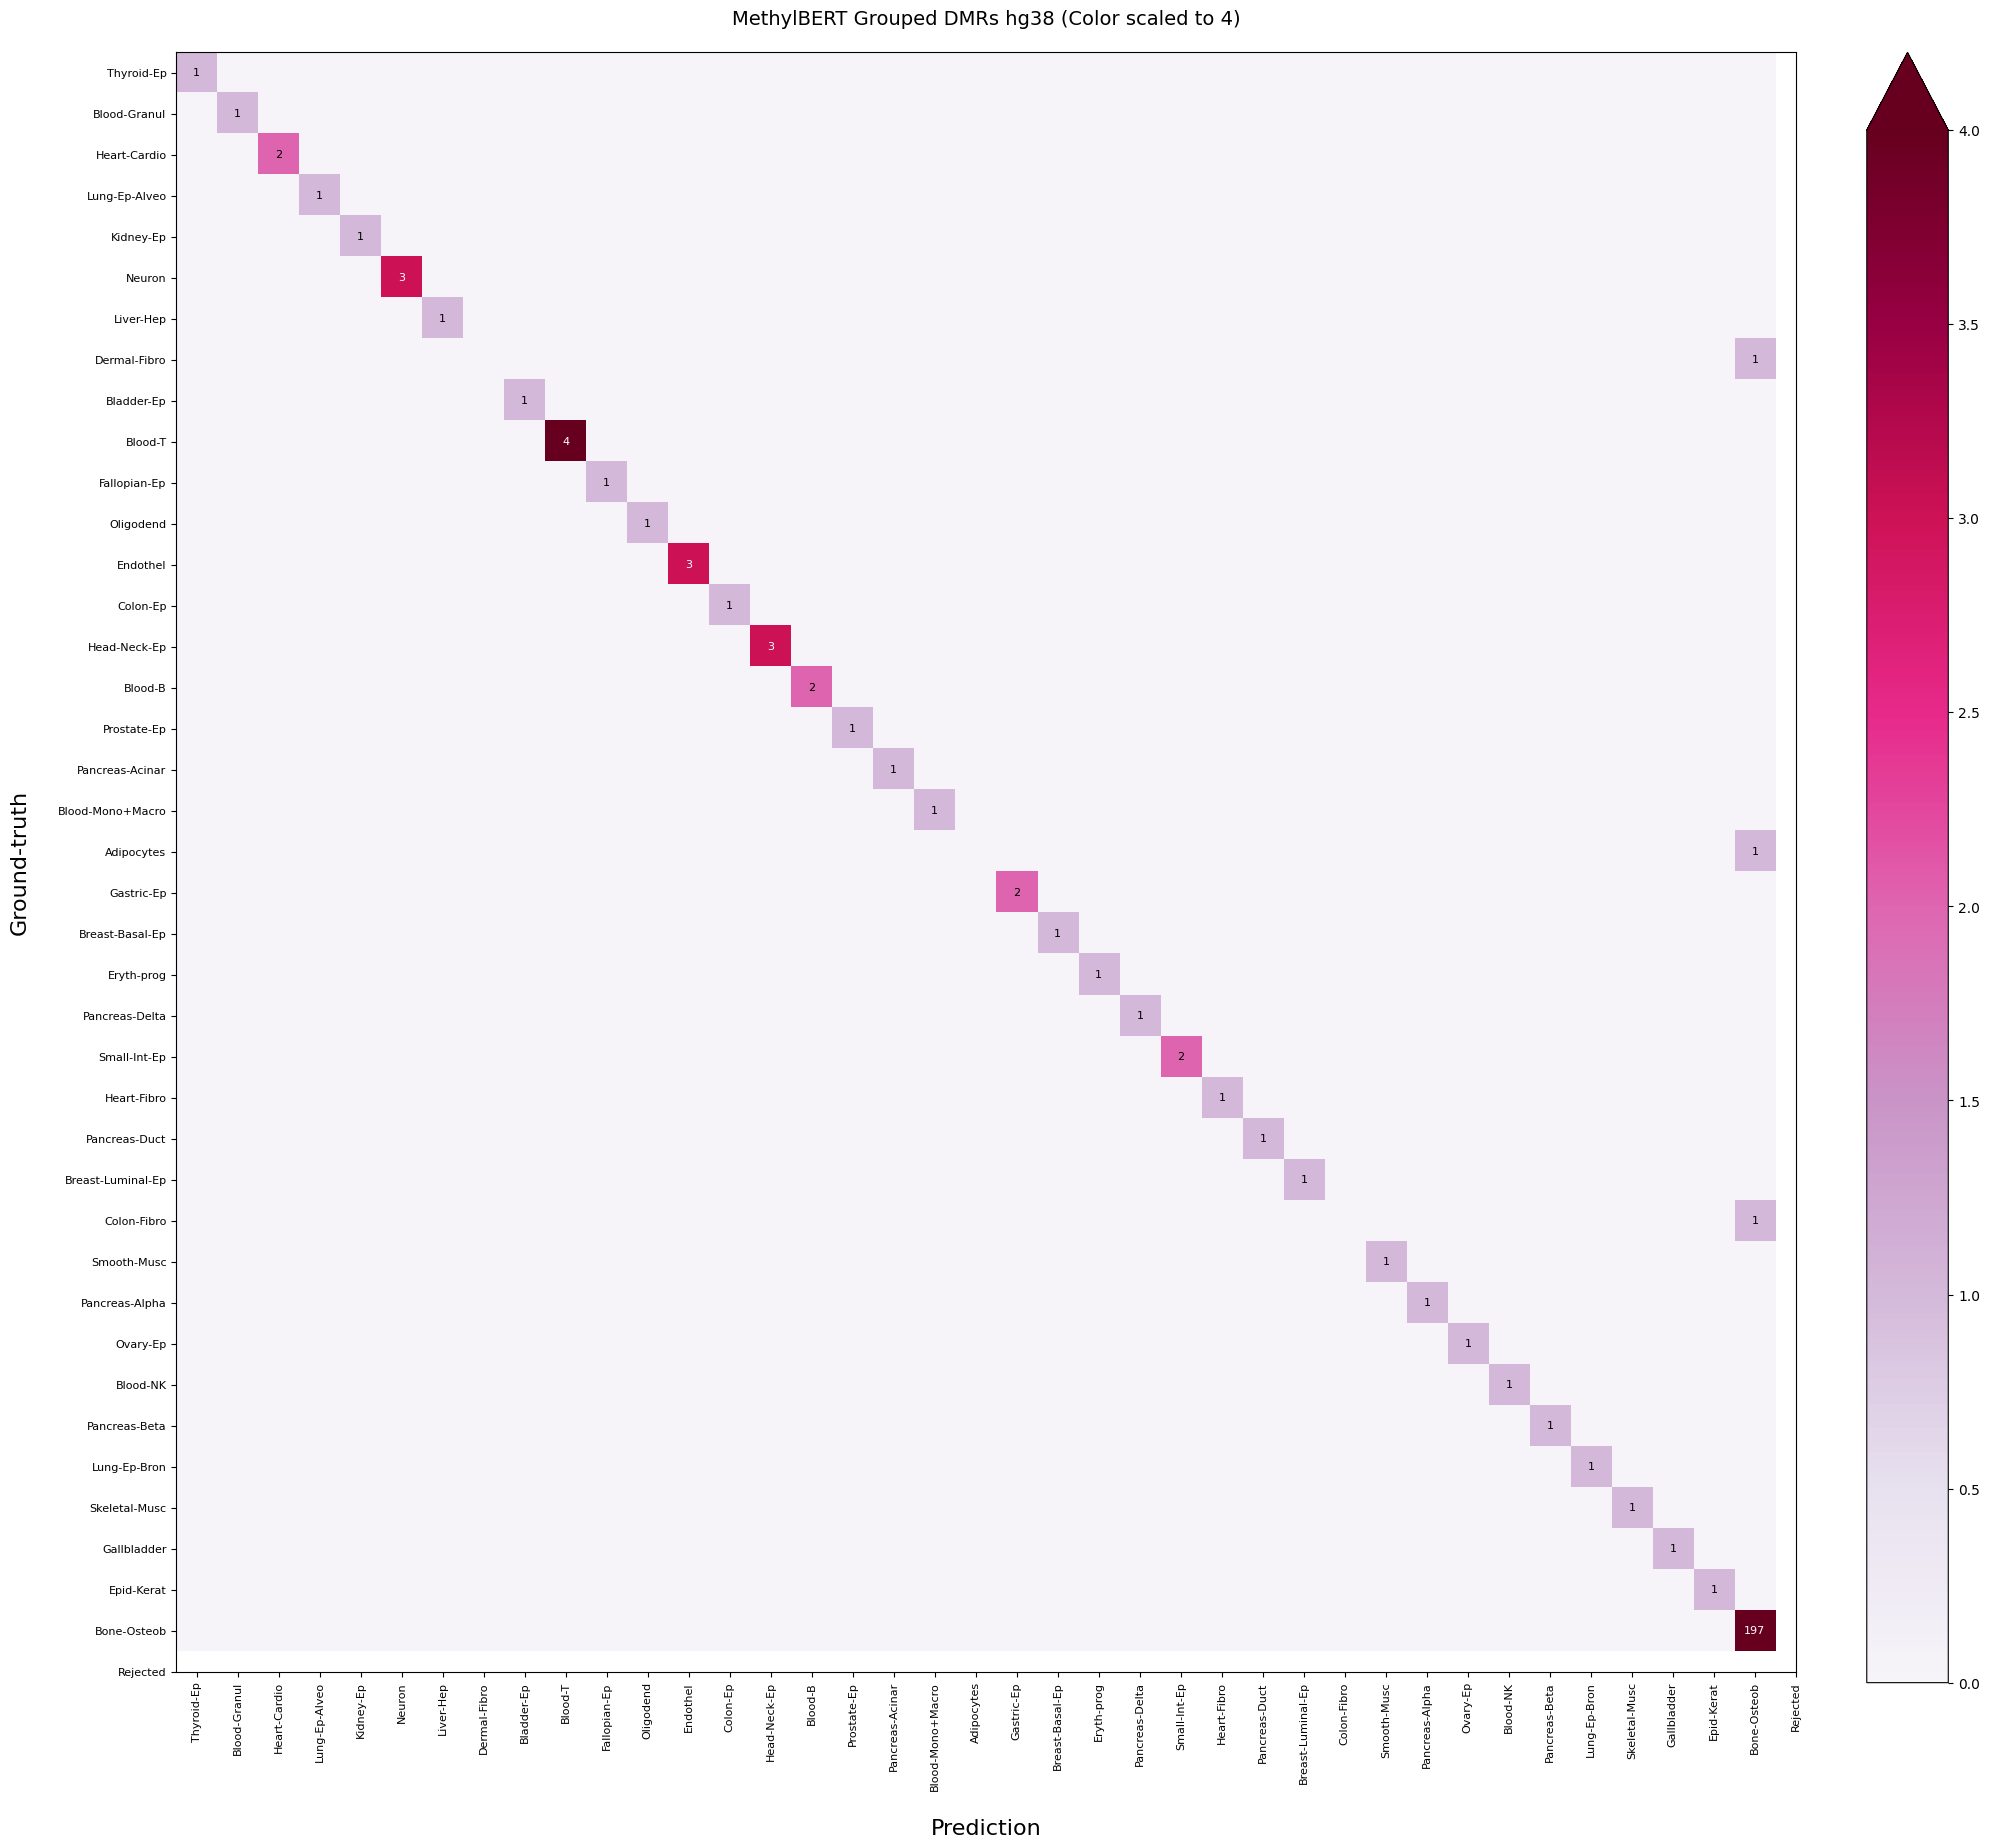

In [46]:
plot_confusion_matrix_for_target_confidence(
    predictions,
    confidence,
    target_confidence=0.75,
    labels=labels,
    labels_list=labels_list,
    title="MethylBERT Grouped DMRs hg38",
)

## Pseudo-bulk deconvolutions

Generate predictions for train and validation data

In [23]:
res_train = model_instance.predict(train_dataset)
res_train_pd = pd.DataFrame(
    res_train[0], columns=["prediction_" + str(x) for x in range(40)]
)
train_data = pd.concat([all_data[all_data["split"] == "train"], res_train_pd], axis=1)

/home/luna.kuleuven.be/u0169940/Repos/methyldl/methyldl/modelling/methylbert.py:581: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


OUTPUT DIR IS: tmp_trainer


We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (0) is identical to the `bos_token_id` (0), `eos_token_id` (None), or the `sep_token_id` (None), and your input is not padded.


In [24]:
res_valid = model_instance.predict(valid_dataset)
res_valid_pd = pd.DataFrame(
    res_valid[0], columns=["prediction_" + str(x) for x in range(40)]
)
valid_data = pd.concat([all_data[all_data["split"] == "valid"], res_valid_pd], axis=1)

In [ ]:
# with open("../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_3_minlen_10/methylbert_deconv_prepared_splits_hg38.pkl", "wb") as f:
#     pickle.dump((train_data, valid_data,test_data),f)

Generate deconvolution input-output pairs

1. The set of target proportions is the same for each split - the data is different. 
2. Follows assumption that all reads are IID (will not work with targeted protocols and must be adjusted for them)
3. Proportion of on-target reads vs off-target for each dmr cell type group is dependent on number of cells in mixture and target cell-types. 
    - for example, if mixture only has cell type zero, then all reads in corresponding DMR region will be on-target, while all reads in other regions will be off-target. 
    - for case with two cell-types (zero, one), d% and (1-d)% of reads in DMR-0 and DMR-1 will be on target and reads in remaining DMRs will all be off-target (where d is the proportion of cell type 0).
4. OVVERIDEN BY NECESSISITY FOR CLASSIFIER TO BE ABLE TO PREDICT ALL LABELS -->  Avoids labels 8,16,30,37,38 in the mixture because the source files for these labels are shared between train/valid/test

In [13]:
with open(
    "../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_4_minlen_10/methylbert_deconv_prepared_splits_hg38.pkl",
    "rb",
) as f:
    train_data, valid_data, test_data = pickle.load(f)

In [11]:
train_file_counts = set(
    pd.DataFrame(
        train_data["file"][
            train_data["dmr_ctype_label"] == train_data["original_label"]
        ].value_counts()
    ).reset_index()["file"]
)
valid_file_counts = set(
    pd.DataFrame(
        valid_data["file"][
            valid_data["dmr_ctype_label"] == valid_data["original_label"]
        ].value_counts()
    ).reset_index()["file"]
)
test_file_counts = set(
    pd.DataFrame(
        test_data["file"][
            test_data["dmr_ctype_label"] == test_data["original_label"]
        ].value_counts()
    ).reset_index()["file"]
)

In [14]:
all_data = pd.concat([train_data, valid_data, test_data])

In [16]:
all_data.reset_index(inplace=True)

In [17]:
all_data["ctype"] = all_data["original_label"].apply(lambda x: labels_dict[x])

NameError: name 'labels_dict' is not defined

In [30]:
manual_common_files = set(
    all_data[["original_label", "ctype", "file"]][
        all_data["original_label"].apply(lambda x: x in [28, 35])
    ]
    .groupby(["original_label", "ctype", "file"])
    .count()
    .reset_index()["file"]
)

In [31]:
train_files = (
    train_file_counts.difference(valid_file_counts)
    .difference(test_file_counts)
    .difference(manual_common_files)
)
valid_files = (
    valid_file_counts.difference(train_file_counts)
    .difference(test_file_counts)
    .difference(manual_common_files)
)
test_files = (
    test_file_counts.difference(train_file_counts)
    .difference(valid_file_counts)
    .difference(manual_common_files)
)
common_files = train_file_counts.intersection(valid_file_counts).intersection(
    test_file_counts
)
common_files = common_files.union(manual_common_files)

In [32]:
len(train_files) + len(valid_files) + len(test_files) + len(common_files) == len(
    all_data["file"].unique()
)

True

In [33]:
target_columns = [f"prediction_{i}" for i in range(1, 40)]

In [15]:
# Preparing better orginized splits
train_split = all_data[all_data["file"].apply(lambda x: x in train_files)]
valid_split = all_data[all_data["file"].apply(lambda x: x in valid_files)]
test_split = all_data[all_data["file"].apply(lambda x: x in test_files)]

NameError: name 'train_files' is not defined

In [35]:
from sklearn.model_selection import train_test_split

common_subset = all_data[all_data["file"].apply(lambda x: x in common_files)]
common_train, common_test = train_test_split(
    common_subset,
    test_size=0.333,
    stratify=np.array(common_subset["file"]),
    random_state=42,
)
common_train, common_valid = train_test_split(
    common_train,
    test_size=0.5,
    stratify=np.array(common_train["file"]),
    random_state=42,
)

In [36]:
train_split = pd.concat([train_split, common_train])
valid_split = pd.concat([valid_split, common_valid])
test_split = pd.concat([test_split, common_test])

In [ ]:
# for data in [train_split, valid_split, test_split]:
#     data.drop(['input_ids','methylation_ids'], inplace=True, axis=1)

TODO! The direction must be correctly inferred from the data. (Here I pass "U" because in Loyefer Atlas, all reads are in 5'-->3' direction)

In [37]:
for df in [train_split, valid_split, test_split]:
    df["is_cell_informative_region"] = df["original_label"] == df["dmr_ctype_label"]
    df["prediction"] = np.argmax(df[target_columns], 1)
    df["confidence"] = np.max(df[target_columns], 1)
    # df["total_marked_cpgs"] = df["original_methyl"].apply(lambda x: len(x.replace(".","")))
    df["total_marked_cpgs"] = df["methylated_CpGs"] + df["unmethylated_CpGs"]
    # df["U"] = df["original_methyl"].apply(lambda x: x.count("T"))
    # df["X"] = df["original_methyl"].apply(lambda x: x.count("."))
    # df["M"] = df["original_methyl"].apply(lambda x: x.count("C"))
    # df["UXM_count"] = df["original_methyl"].apply(lambda x: len(x))
    df["direction"] = "U"  # TODO: Must be inferred fromt the .bam file
    # df["read_start"] = df["ref_pos"]
    # df["read_end"] =  df["ref_pos"] + df["read_length"]
    df["read_start"] = df["trimmed_start"]
    df["read_end"] = df["trimmed_end"]
    df.rename(columns={"chr": "chromosome"}, inplace=True)

In [12]:
import sys

repo_path = os.path.abspath("../../UXM_deconv/src")
if repo_path not in sys.path:
    sys.path.append(repo_path)
from src.deconv import load_atlas, decon_single_samp

atlas_location = "../../UXM_deconv/supplemental/Atlas.U25.l4.hg38.full.tsv"
atlas, ref_cells = load_atlas(atlas_location)

In [18]:
labels_dict = {
    int(value["original_label"]): key
    for (key, value) in test_split[["original_label", "ctype"]]
    .groupby("ctype")
    .mean()
    .to_dict(orient="index")
    .items()
}
labels_dict_reversed = {y: x for (x, y) in labels_dict.items()}

NameError: name 'test_split' is not defined

In [397]:
# test_example = deepcopy(results_agg[results_agg["file"]==sample_name])
# sf = deepcopy(test_example[["name", "direction"]])
# sf[sample_name] = test_example["sf"]
# counts = test_example[["name", "direction", "count"]]
# counts.columns = ["name", "direction", sample_name]
# uxm_deconv_results = uxm_deconvolution(atlas, ref_cells, sf, counts, sample_names = [sample_name])[0]
# uxm_deconv_results ={x:np.round(y,4) for (x,y) in zip(ref_cells, uxm_deconv_results)}
# uxm_res_dict[sample_name] = uxm_deconv_results

In [12]:
atlas = atlas.sort_values(by=["chr", "start", "end"], ascending=True).reset_index(
    drop=True
)

In [41]:
valid_split_uxm_input = valid_split.sort_values(
    by=["chromosome", "read_start", "read_end"], ascending=True
).reset_index(drop=True)
train_split_uxm_input = train_split.sort_values(
    by=["chromosome", "read_start", "read_end"], ascending=True
).reset_index(drop=True)
test_split_uxm_input = test_split.sort_values(
    by=["chromosome", "read_start", "read_end"], ascending=True
).reset_index(drop=True)

In [ ]:
# train_split_uxm_input = prepare_reads_for_uxm(train_split, atlas, labels_dict, cell_type_match_dict,
#                                               seq_column = "input_ids",
#                                               debug=True,
#                                               methylation_pattern_column = "methylation_ids",
#                                               read_name_column = "read_id")

# valid_split_uxm_input = prepare_reads_for_uxm(valid_split, atlas, labels_dict, cell_type_match_dict,
#                                               seq_column = "input_ids",
#                                               debug=True,
#                                               methylation_pattern_column = "methylation_ids",
#                                               read_name_column = "read_id")

# test_split_uxm_input = prepare_reads_for_uxm(test_split, atlas, labels_dict, cell_type_match_dict,
#                                               seq_column = "input_ids",
#                                               debug=True,
#                                               methylation_pattern_column = "methylation_ids",
#                                               read_name_column = "read_id")

Regenerating predictions

In [ ]:
# with open("../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_4_minlen_10/methylbert_deconv_prepared_splits_hg38.pkl", "wb") as f:
#     pickle.dump((train_split_uxm_input, valid_split_uxm_input,test_split_uxm_input),f)

TODO: 

2. Change generate_pseudo_bulk logic by adapting to uxm prepared data(remove incorrect uxm code / compute deconvolution results for different value of methylation thresholds)
3. Make sure that allowed_labels below are the ones that supported by Loyfer UXM (35 of 39 cell types, if I am not mistaken)

In [ ]:
# with open("../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_4_minlen_10/methylbert_deconv_prepared_splits_hg38.pkl", "rb") as f:
#     train_split_uxm_input, valid_split_uxm_input,test_split_uxm_input = pickle.load(f)

In [19]:
with open("methylbert_deconv_prepared_splits_hg38_uxm_ready.pkl", "rb") as f:
    train_split_uxm_input, valid_split_uxm_input, test_split_uxm_input = pickle.load(f)

In [ ]:
# # Filtering reads with NCPGS <4
# train_split_uxm_input = train_split_uxm_input[train_split_uxm_input["NCPGS"]>3]
# valid_split_uxm_input = valid_split_uxm_input[valid_split_uxm_input["NCPGS"]>3]
# test_split_uxm_input = test_split_uxm_input[test_split_uxm_input["NCPGS"]>3]

In [13]:
seq_length

150

In [12]:
train_split_uxm_input_list = prepare_methylbert_list_inference(
    train_split_uxm_input.rename(
        columns={"seq": "input_ids", "pattern": "methylation_ids"}
    ),
    dmr_label_column=dmr_label_column,
    seq_length=seq_length,
)
train_split_uxm_input_dataset = MethylBertFinetuneDataset(
    data_source=train_split_uxm_input_list,
    vocab=MethylVocab(k=3),
    seq_len=seq_length,
    lazy_tokenization=True,
)

valid_split_uxm_input_list = prepare_methylbert_list_inference(
    valid_split_uxm_input.rename(
        columns={"seq": "input_ids", "pattern": "methylation_ids"}
    ),
    dmr_label_column=dmr_label_column,
    seq_length=seq_length,
)
valid_split_uxm_input_dataset = MethylBertFinetuneDataset(
    data_source=valid_split_uxm_input_list,
    vocab=MethylVocab(k=3),
    seq_len=seq_length,
    lazy_tokenization=True,
)

test_split_uxm_input_list = prepare_methylbert_list_inference(
    test_split_uxm_input.rename(
        columns={"seq": "input_ids", "pattern": "methylation_ids"}
    ),
    dmr_label_column=dmr_label_column,
    seq_length=seq_length,
)
test_split_uxm_input_dataset = MethylBertFinetuneDataset(
    data_source=test_split_uxm_input_list,
    vocab=MethylVocab(k=3),
    seq_len=seq_length,
    lazy_tokenization=True,
)

res_train = model_instance.predict(train_split_uxm_input_dataset)
res_train_pd = pd.DataFrame(
    res_train[0], columns=["prediction_" + str(x) for x in range(40)]
)
train_split_uxm_input = pd.concat([train_split_uxm_input, res_train_pd], axis=1)

res_valid = model_instance.predict(valid_split_uxm_input_dataset)
res_valid_pd = pd.DataFrame(
    res_valid[0], columns=["prediction_" + str(x) for x in range(40)]
)
valid_split_uxm_input = pd.concat([valid_split_uxm_input, res_valid_pd], axis=1)

res_test = model_instance.predict(test_split_uxm_input_dataset)
res_test_pd = pd.DataFrame(
    res_test[0], columns=["prediction_" + str(x) for x in range(40)]
)
test_split_uxm_input = pd.concat([test_split_uxm_input, res_valid_pd], axis=1)

Building Vocab
Total number of sequences: 5032765
Using lazy tokenization (on-the-fly processing)
Building Vocab
Total number of sequences: 2355348
Using lazy tokenization (on-the-fly processing)
Building Vocab
Total number of sequences: 2575954
Using lazy tokenization (on-the-fly processing)
OUTPUT DIR IS: tmp_trainer


/home/luna.kuleuven.be/u0169940/Repos/methyldl/methyldl/modelling/methylbert.py:581: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (0) is identical to the `bos_token_id` (0), `eos_token_id` (None), or the `sep_token_id` (None), and your input is not padded.


In [ ]:
# with open("methylbert_deconv_prepared_splits_hg38_uxm_ready_with_predictions.pkl", "wb") as f:
#     pickle.dump((train_split_uxm_input, valid_split_uxm_input,test_split_uxm_input),f)

In [20]:
with open(
    "../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_4_minlen_10/methylbert_deconv_prepared_splits_hg38.pkl",
    "rb",
) as f:
    train_split_uxm_input, valid_split_uxm_input, test_split_uxm_input = pickle.load(f)

In [21]:
labels_dict = {
    int(value["dmr_ctype_label"]): key
    for (key, value) in train_split_uxm_input[["dmr_ctype_label", "dmr_ctype"]]
    .groupby("dmr_ctype")
    .mean()
    .to_dict(orient="index")
    .items()
}

In [22]:
labels_dict_reversed = {y: x for (x, y) in labels_dict.items()}

In [23]:
ref_pos = np.array(
    [
        labels_dict_reversed[cell] if cell in labels_dict_reversed.keys() else -1
        for cell in ref_cells
    ]
)

In [ ]:
allowed_labels = [x for x in range(39)]
n_cells_max = 10  # Maximum number of cells in mixture.
n_io_examples = 5  # Number of examples per split
n_read_per_split = (
    4.75 * 1e5
)  # Number of reads based on which information is aggregated.
all_ios = []
exceptions = []
for i in tqdm(range(n_io_examples)):
    try:
        labels, proportions = random_select_with_weights(allowed_labels, n_cells_max)
        _, proportions, subs, uxm_data = generate_pseudo_bulk(
            n_read_per_split,
            labels,
            proportions,
            train_split_uxm_input,
            valid_split_uxm_input,
            test_split_uxm_input,
            atlas,
            ref_cells,
            labels_dict_reversed,
        )
        all_ios.append((proportions, subs, uxm_data))
    except:
        exceptions.append((labels, proportions))
    # if not i %1000:
    #     with open("30000_ios_deconvolution_data_hg38_grouped_dmrs.pkl", "wb") as f:
    #         pickle.dump(all_ios, f)

In [9]:
all_ios, exceptions = run_ios_generation_parallel(
    train_split_uxm_input,
    valid_split_uxm_input,
    test_split_uxm_input,
    batch_size=10,
    n_workers=20,
    n_io_examples=45_000,
    start_checkpoint_idx=266000,
    checkpoint_interval=1_000,
    file_name="../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_4_minlen_10/ios_deconvolution/ios_deconvolution_data_hg38_grouped_dmrs_uxm_alligned.pkl",
)

Generating examples:   0%|          | 0/45000 [00:00<?, ?it/s]

Generating examples: 100%|██████████| 45000/45000 [4:31:51<00:00,  2.76it/s]  


In [ ]:
# all_ios = []
# for file in os.listdir("../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_3_minlen_10/ios_deconvolution/"):
#     with open(f"../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_3_minlen_10/ios_deconvolution/{file}", "rb") as f:
#         all_ios.extend(pickle.load(f))

In [ ]:
# with open("../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_3_minlen_10/ios_deconvolution_data_hg38_grouped_dmrs_uxm_alligned.pkl", "wb") as f:
#      pickle.dump(all_ios, f)

In [20]:
with open(
    "../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_4_minlen_10/ios_deconvolution_data_hg38_grouped_dmrs_uxm_alligned.pkl",
    "rb",
) as f:
    all_ios = pickle.load(f)

In [ ]:
# uxm_deconvolution_results = []
# ref_cells = [x for x in ref_cells if x!="Megakaryocytes"]
# for i in tqdm(range(len(all_ios))):
#     interim_result = []
#     for j in range(3):
#         sf = all_ios[i][2][j][0]
#         counts = all_ios[i][2][j][1]
#         uxm_proportions = uxm_deconvolution(atlas, ref_cells, sf, counts, sample_names = ["pseudo_balk_sample"])[0]
#         uxm_deconv_results ={x:np.round(y,4) for (x,y) in zip(ref_cells, uxm_proportions)}
#         uxm_deconv_results_alligned = rearange_uxm_deconvolution_results(labels_dict_reversed, uxm_proportions, ref_cells)
#         interim_result.append(uxm_deconv_results_alligned)
#     uxm_deconvolution_results.append(interim_result)

100%|██████████| 30000/30000 [09:14<00:00, 54.14it/s]


In [195]:
pd.options.display.float_format = "{:.3f}".format

Models definiton

Training


In [ ]:
# with open("30000_ios_deconvolution_data_hg38_grouped_dmrs.pkl", "rb") as f:
#     all_ios = pickle.load(f)

In [21]:
train_features = np.array(
    [
        np.array(all_ios[k][1][0][[f"prediction_{i}_wavg" for i in range(40)]])
        for k in range(len(all_ios))
    ]
)
valid_features = np.array(
    [
        np.array(all_ios[k][1][1][[f"prediction_{i}_wavg" for i in range(40)]])
        for k in range(len(all_ios))
    ]
)
test_features = np.array(
    [
        np.array(all_ios[k][1][2][[f"prediction_{i}_wavg" for i in range(40)]])
        for k in range(len(all_ios))
    ]
)
train_outputs = valid_outputs = test_outputs = np.array(
    [np.array(all_ios[k][0]) for k in range(len(all_ios))]
)

Liver-Hep 0.254 0.402 0.399 0.4
Adipocytes 0.192 0.177 0.162 0.171
Breast-Basal-Ep 0.297 0.362 0.366 0.399
Pancreas-Beta 0.257 0.267 0.274 0.262


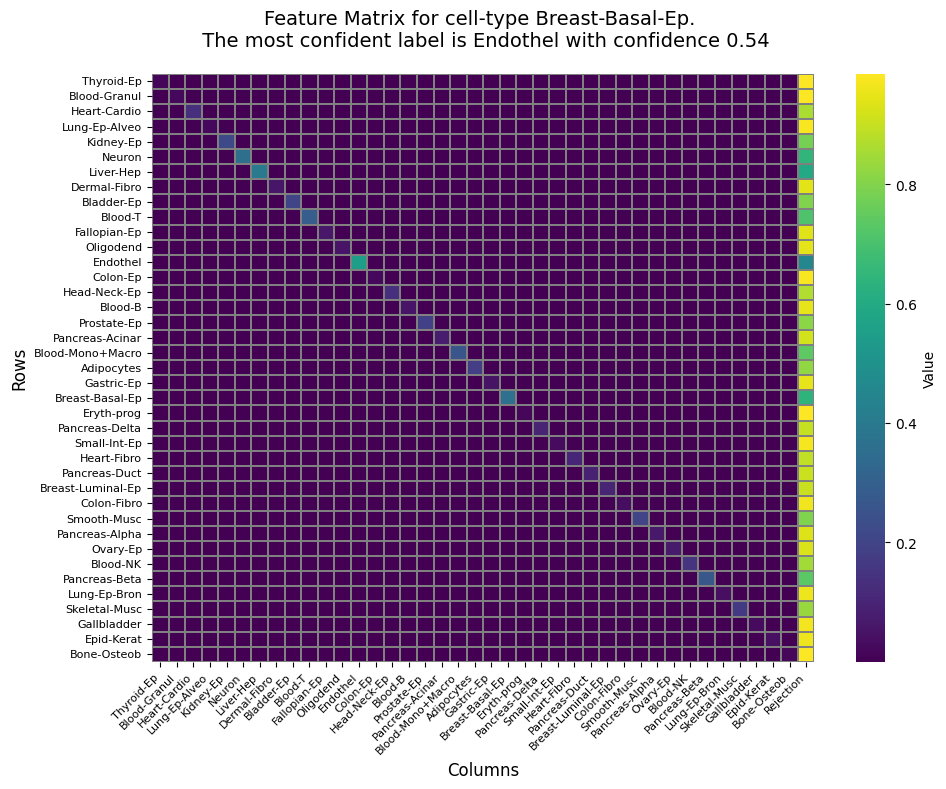

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# target = 2

# labels, proportions = ([0,1,2,3,4,5,6,7,8,9],[0.1]*10)
# _, proportions, subs,uxm_data = generate_pseudo_bulk(n_read_per_split, labels,proportions, train_split_uxm_input,valid_split_uxm_input, test_split_uxm_input,atlas,ref_cells,labels_dict_reversed)

# matrix = subs[2][[f"prediction_{i}_wavg" for i in range(40)]]

i = 0
# labels, proportions = lab_prop_par[i]
# matrix_p = all_ios_parallel[i][1][2][[f"prediction_{i}_wavg" for i in range(40)]]
# matrix_l = all_ios[i][1][2][[f"prediction_{i}_wavg" for i in range(40)]]
subs = all_ios[i][1]
proportions = np.array(all_ios[i][0])
labels = np.where(proportions > 0)[0]
matrix = all_ios[i][1][0][[f"prediction_{i}_wavg" for i in range(40)]]
matrix_v = all_ios[i][1][1][[f"prediction_{i}_wavg" for i in range(40)]]
matrix_t = all_ios[i][1][2][[f"prediction_{i}_wavg" for i in range(40)]]
diagonal = np.diag(matrix)
diagonal_v = np.diag(matrix_v)
diagonal_t = np.diag(matrix_t)

# diagonal_l = np.diag(matrix_l)

# for i in labels:
#     print(labels_dict[i], round(proportions[i],3),round(diagonal[i],3),round(diagonal_l[i],3) )

for i in labels:
    print(
        labels_dict[i],
        round(proportions[i], 3),
        round(diagonal[i], 3),
        round(diagonal_v[i], 3),
        round(diagonal_t[i], 3),
    )


target = np.where(proportions == max(proportions))[0][0]
most_confident_idx = np.where(diagonal == max(diagonal))[0][0]
most_confident_value = diagonal[most_confident_idx]

# Create row and column labels
row_labels = subs[2]["dmr_ctype"]
column_labels = deepcopy(row_labels).to_list()
column_labels.append("Rejection")

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    matrix,
    xticklabels=column_labels,
    yticklabels=row_labels,
    cmap="viridis",  # or try 'YlOrRd', 'Blues', 'RdYlBu_r'
    cbar_kws={"label": "Value"},
    linewidths=0.1,
    linecolor="gray",
)

plt.title(
    f"Feature Matrix for cell-type {labels_dict[target]}. \n The most confident label is {labels_dict[most_confident_idx]} with confidence {most_confident_value:.2f}",
    fontsize=14,
    pad=20,
)
plt.xlabel("Columns", fontsize=12)
plt.ylabel("Rows", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

Predicting and visualizing

In [23]:
labels_dict = {
    x: y
    for (x, y) in zip(
        all_ios[0][1][0]["dmr_ctype_label"], all_ios[0][1][0]["dmr_ctype"]
    )
}

In [24]:
import numpy as np
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from dataclasses import dataclass, field
from typing import Optional, Literal, Dict
from copy import deepcopy


@dataclass
class XGBDeconvolverConfig:
    """Configuration for XGBoost Deconvolver."""

    n_estimators: int = 200
    max_depth: int = 6
    learning_rate: float = 0.1
    subsample: float = 0.8
    colsample_bytree: float = 0.8
    min_child_weight: int = 3
    reg_alpha: float = 0.1
    reg_lambda: float = 1.0
    early_stopping_rounds: Optional[int] = 20
    random_state: int = 42


@dataclass
class XGBTrainingHistory:
    """Stores training metrics matching PyTorch version."""

    train_loss: list = field(default_factory=list)
    train_mae: list = field(default_factory=list)
    train_mse: list = field(default_factory=list)
    train_kl: list = field(default_factory=list)
    train_max_error: list = field(default_factory=list)
    train_cosine_sim: list = field(default_factory=list)
    val_loss: list = field(default_factory=list)
    val_mae: list = field(default_factory=list)
    val_mse: list = field(default_factory=list)
    val_kl: list = field(default_factory=list)
    val_max_error: list = field(default_factory=list)
    val_cosine_sim: list = field(default_factory=list)
    best_iteration: int = 0
    stopped_early: bool = False

    def to_dict(self) -> dict:
        return {
            "train_loss": self.train_loss,
            "train_mae": self.train_mae,
            "train_mse": self.train_mse,
            "train_kl": self.train_kl,
            "train_max_error": self.train_max_error,
            "train_cosine_sim": self.train_cosine_sim,
            "val_loss": self.val_loss,
            "val_mae": self.val_mae,
            "val_mse": self.val_mse,
            "val_kl": self.val_kl,
            "val_max_error": self.val_max_error,
            "val_cosine_sim": self.val_cosine_sim,
            "best_iteration": self.best_iteration,
            "stopped_early": self.stopped_early,
        }


def compute_deconvolution_metrics_np(
    pred: np.ndarray, target: np.ndarray, eps: float = 1e-8
) -> Dict[str, float]:
    """
    Compute all evaluation metrics (NumPy version).

    Matches the PyTorch `compute_deconvolution_metrics` function.
    """
    # Ensure 2D
    if pred.ndim == 1:
        pred = pred[np.newaxis, :]
        target = target[np.newaxis, :]

    # MAE
    mae = np.abs(pred - target).mean()

    # MSE
    mse = ((pred - target) ** 2).mean()

    # KL Divergence: sum over classes, mean over samples
    target_safe = np.clip(target, eps, None)
    pred_safe = np.clip(pred, eps, None)
    kl = (target_safe * (np.log(target_safe) - np.log(pred_safe))).sum(axis=-1).mean()

    # Max error (worst case across all samples and classes)
    max_error = np.abs(pred - target).max()

    # Cosine similarity (average across batch)
    dot_product = (pred * target).sum(axis=-1)
    pred_norm = np.linalg.norm(pred, axis=-1)
    target_norm = np.linalg.norm(target, axis=-1)
    cosine_sim = (dot_product / (pred_norm * target_norm + eps)).mean()

    return {
        "mae": float(mae),
        "mse": float(mse),
        "kl": float(kl),
        "max_error": float(max_error),
        "cosine_sim": float(cosine_sim),
    }


def compute_combined_loss(
    pred: np.ndarray,
    target: np.ndarray,
    mse_weight: float = 1.0,
    kl_weight: float = 0.5,
    eps: float = 1e-8,
) -> float:
    """Compute combined MSE + KL loss matching PyTorch version."""
    mse = ((pred - target) ** 2).mean()
    target_safe = np.clip(target, eps, None)
    pred_safe = np.clip(pred, eps, None)
    kl = (target_safe * (np.log(target_safe) - np.log(pred_safe))).sum(axis=-1).mean()
    return mse_weight * mse + kl_weight * kl


class XGBoostDeconvolver:
    """
    XGBoost-based deconvolver using diagonal and rejection features.

    Uses only:
    - Diagonal elements: x[i, i] for i in 0..n_dmr-1 (39 features)
    - Rejection column: x[:, -1] (39 features)
    Total: 78 features → 39 cell type proportions

    Parameters
    ----------
    n_dmr_groups : int
        Number of DMR groups (default: 39)
    n_pred_classes : int
        Number of prediction classes including rejection (default: 40)
    n_cell_types : int
        Number of output cell types (default: 39)
    config : XGBDeconvolverConfig
        XGBoost hyperparameters
    output_transform : str
        How to handle outputs:
        - 'none': Direct prediction (use when targets are proportions)
        - 'clip_normalize': Clip to [0,∞) and normalize to sum=1
        - 'softmax': Apply softmax (use when training on logits)
    """

    def __init__(
        self,
        n_dmr_groups: int = 39,
        n_pred_classes: int = 40,
        n_cell_types: int = 39,
        config: Optional[XGBDeconvolverConfig] = None,
        output_transform: Literal[
            "none", "clip_normalize", "softmax"
        ] = "clip_normalize",
    ):
        self.n_dmr = n_dmr_groups
        self.n_pred_classes = n_pred_classes
        self.n_cell_types = n_cell_types
        self.config = config or XGBDeconvolverConfig()
        self.output_transform = output_transform

        self.n_features = n_dmr_groups * 2  # diagonal + reject column

        self.model = None
        self.best_model = None
        self.history = None
        self._is_fitted = False

    def _build_model(self, verbose=0) -> MultiOutputRegressor:
        """Build XGBoost multi-output regressor."""
        base_model = xgb.XGBRegressor(
            n_estimators=self.config.n_estimators,
            max_depth=self.config.max_depth,
            learning_rate=self.config.learning_rate,
            subsample=self.config.subsample,
            colsample_bytree=self.config.colsample_bytree,
            min_child_weight=self.config.min_child_weight,
            reg_alpha=self.config.reg_alpha,
            reg_lambda=self.config.reg_lambda,
            random_state=self.config.random_state,
            n_jobs=-1,
            verbosity=verbose,
        )
        return MultiOutputRegressor(base_model)

    def extract_features(self, X: np.ndarray) -> np.ndarray:
        """
        Extract diagonal and rejection column features.

        Parameters
        ----------
        X : np.ndarray
            Input array of shape (n_samples, n_dmr_groups, n_pred_classes)

        Returns
        -------
        features : np.ndarray
            Extracted features of shape (n_samples, n_dmr_groups * 2)
        """
        if X.ndim == 2:
            X = X[np.newaxis, ...]

        n_samples = X.shape[0]

        # Extract diagonal: x[i, i] for i in 0..n_dmr-1
        diagonal = np.array(
            [np.diag(X[i, :, : self.n_dmr]) for i in range(n_samples)]
        )  # (n_samples, 39)

        # Extract rejection column (last column)
        reject_col = X[:, :, -1]  # (n_samples, 39)

        # Concatenate features
        features = np.concatenate([diagonal, reject_col], axis=1)

        return features

    def _transform_output(self, raw_output: np.ndarray) -> np.ndarray:
        """
        Transform raw model outputs to valid proportions.
        """
        if self.output_transform == "none":
            # Just ensure valid proportions
            output = np.clip(raw_output, 0, 1)
            row_sums = output.sum(axis=1, keepdims=True)
            # Only normalize if sum > 0
            row_sums = np.where(row_sums == 0, 1, row_sums)
            return output / row_sums

        elif self.output_transform == "clip_normalize":
            # Clip negative values and normalize
            clipped = np.clip(raw_output, 0, None)
            row_sums = clipped.sum(axis=1, keepdims=True)
            row_sums = np.where(row_sums == 0, 1, row_sums)
            return clipped / row_sums

        elif self.output_transform == "softmax":
            # Softmax (use only if training on log-odds/logits)
            exp_out = np.exp(raw_output - np.max(raw_output, axis=1, keepdims=True))
            return exp_out / exp_out.sum(axis=1, keepdims=True)

        else:
            raise ValueError(f"Unknown output_transform: {self.output_transform}")

    def _predict_raw(self, X_features: np.ndarray) -> np.ndarray:
        """Get raw model predictions without transformation."""
        return self.model.predict(X_features)

    def fit(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_val: Optional[np.ndarray] = None,
        y_val: Optional[np.ndarray] = None,
        loss_weights: Optional[Dict[str, float]] = None,
        early_stopping_metric: Literal[
            "val_loss",
            "val_mae",
            "val_mse",
            "val_kl",
            "val_max_error",
            "val_cosine_sim",
        ] = "val_mae",
        verbose: int = 1,
    ) -> "XGBoostDeconvolver":
        """
        Fit the XGBoost deconvolver with metric tracking.

        Parameters
        ----------
        X_train : np.ndarray
            Training data of shape (n_samples, n_dmr_groups, n_pred_classes)
        y_train : np.ndarray
            Training labels of shape (n_samples, n_cell_types)
        X_val : np.ndarray, optional
            Validation data
        y_val : np.ndarray, optional
            Validation labels
        loss_weights : dict, optional
            Weights for combined loss: {'mse': float, 'kl': float}
        early_stopping_metric : str
            Metric to monitor for early stopping
        verbose : int
            Verbosity level (0=silent, 1=progress, 2=detailed)

        Returns
        -------
        self : XGBoostDeconvolver
        """
        if loss_weights is None:
            loss_weights = {"mse_weight": 1.0, "kl_weight": 0.5}

        # Determine if we should maximize or minimize
        maximize_metrics = {"val_cosine_sim"}
        minimize = early_stopping_metric not in maximize_metrics

        # Extract features
        X_train_feat = self.extract_features(X_train)
        X_val_feat = self.extract_features(X_val) if X_val is not None else None

        if verbose:
            print(f"Training XGBoost Deconvolver")
            print(f"  Input shape: {X_train.shape} → Features: {X_train_feat.shape}")
            print(f"  Output shape: {y_train.shape}")
            print(f"  Output transform: {self.output_transform}")
            print(f"  Early stopping on: {early_stopping_metric}")
            print("-" * 60)

        # Initialize history
        self.history = XGBTrainingHistory()

        # For proper early stopping, we'll train incrementally
        best_score = float("inf") if minimize else float("-inf")
        patience_counter = 0
        best_iteration = 0

        # Build fresh model
        self.model = self._build_model(verbose=verbose)

        # Train for n_estimators rounds, checking validation each time
        # Note: This is a workaround since sklearn's MultiOutputRegressor
        # doesn't support per-round callbacks easily

        # For simplicity, we'll train the full model first, then evaluate
        # If you need true incremental training, use the Native version below

        self.model.fit(X_train_feat, y_train)

        # Compute final metrics
        train_pred_raw = self._predict_raw(X_train_feat)
        train_pred = self._transform_output(train_pred_raw)
        train_metrics = compute_deconvolution_metrics_np(train_pred, y_train)
        train_loss = compute_combined_loss(train_pred, y_train, **loss_weights)

        self.history.train_loss.append(train_loss)
        self.history.train_mae.append(train_metrics["mae"])
        self.history.train_mse.append(train_metrics["mse"])
        self.history.train_kl.append(train_metrics["kl"])
        self.history.train_max_error.append(train_metrics["max_error"])
        self.history.train_cosine_sim.append(train_metrics["cosine_sim"])

        if X_val is not None and y_val is not None:
            val_pred_raw = self._predict_raw(X_val_feat)
            val_pred = self._transform_output(val_pred_raw)
            val_metrics = compute_deconvolution_metrics_np(val_pred, y_val)
            val_loss = compute_combined_loss(val_pred, y_val, **loss_weights)

            self.history.val_loss.append(val_loss)
            self.history.val_mae.append(val_metrics["mae"])
            self.history.val_mse.append(val_metrics["mse"])
            self.history.val_kl.append(val_metrics["kl"])
            self.history.val_max_error.append(val_metrics["max_error"])
            self.history.val_cosine_sim.append(val_metrics["cosine_sim"])

        self._is_fitted = True

        if verbose:
            print(f"\nTraining Results:")
            print(f"  Train Loss: {train_loss:.4f}")
            print(f"  Train MAE:  {train_metrics['mae']:.4f}")
            print(f"  Train MSE:  {train_metrics['mse']:.4f}")
            print(f"  Train KL:   {train_metrics['kl']:.4f}")
            print(f"  Train Max Error: {train_metrics['max_error']:.4f}")
            print(f"  Train Cosine Sim: {train_metrics['cosine_sim']:.4f}")

            if X_val is not None:
                print(f"\nValidation Results:")
                print(f"  Val Loss:   {val_loss:.4f}")
                print(f"  Val MAE:    {val_metrics['mae']:.4f}")
                print(f"  Val MSE:    {val_metrics['mse']:.4f}")
                print(f"  Val KL:     {val_metrics['kl']:.4f}")
                print(f"  Val Max Error: {val_metrics['max_error']:.4f}")
                print(f"  Val Cosine Sim: {val_metrics['cosine_sim']:.4f}")

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predict cell type proportions.

        Parameters
        ----------
        X : np.ndarray
            Input data of shape (n_samples, n_dmr_groups, n_pred_classes)

        Returns
        -------
        proportions : np.ndarray
            Predicted proportions of shape (n_samples, n_cell_types)
        """
        if not self._is_fitted:
            raise RuntimeError("Model must be fitted before prediction")

        single_sample = X.ndim == 2
        features = self.extract_features(X)

        raw_output = self._predict_raw(features)
        proportions = self._transform_output(raw_output)

        if single_sample:
            proportions = proportions[0]

        return proportions

    def evaluate(
        self,
        X: np.ndarray,
        y: np.ndarray,
        loss_weights: Optional[Dict[str, float]] = None,
    ) -> Dict[str, float]:
        """
        Evaluate model on given data.

        Returns all metrics matching the PyTorch version.
        """
        if loss_weights is None:
            loss_weights = {"mse": 1.0, "kl": 0.5}

        pred = self.predict(X)
        metrics = compute_deconvolution_metrics_np(pred, y)
        metrics["loss"] = compute_combined_loss(pred, y, **loss_weights)

        return metrics

    def get_feature_importance(self, aggregate: bool = True) -> Dict[str, np.ndarray]:
        """Get feature importance scores."""
        if not self._is_fitted:
            raise RuntimeError("Model must be fitted before getting importance")

        importances = np.array(
            [est.feature_importances_ for est in self.model.estimators_]
        )

        if aggregate:
            importances = importances.mean(axis=0)

        return {
            "diagonal": importances[..., : self.n_dmr],
            "reject": importances[..., self.n_dmr :],
            "all": importances,
        }


def train_xgb_deconvolver(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    config: Optional[XGBDeconvolverConfig] = None,
    output_transform: Literal["none", "clip_normalize", "softmax"] = "clip_normalize",
    loss_weights: Optional[Dict[str, float]] = None,
    early_stopping_metric: str = "val_mae",
    early_stopping_patience: int = 15,
    verbose: int = 1,
) -> tuple:
    """
    Convenience function matching the signature pattern of train_matrix_deconvolver.

    Returns
    -------
    model : XGBoostDeconvolver
        Trained model
    history : XGBTrainingHistory
        Training history
    """
    if config is None:
        config = XGBDeconvolverConfig(early_stopping_rounds=early_stopping_patience)

    model = XGBoostDeconvolver(config=config, output_transform=output_transform)

    model.fit(
        X_train,
        y_train,
        X_val,
        y_val,
        loss_weights=loss_weights,
        early_stopping_metric=early_stopping_metric,
        verbose=verbose,
    )

    return model, model.history

In [25]:
config = XGBDeconvolverConfig(
    n_estimators=500,
    max_depth=15,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=1,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=100,
    random_state=42,
)

# Train with metrics
xgb_model, history = train_xgb_deconvolver(
    train_features,
    train_outputs,
    valid_features,
    valid_outputs,
    config=config,
    output_transform="clip_normalize",
    early_stopping_metric="val_mae",
    verbose=1,
    loss_weights={"mse_weight": 1.0, "kl_weight": 5},
)

# xgb_model, history = train_xgb_deconvolver(
#     np.concatenate([train_features, valid_features, test_features]), np.concatenate([train_outputs, valid_outputs, test_outputs]),
#     valid_features, valid_outputs,
#     config=config,
#     output_transform='clip_normalize',
#     early_stopping_metric='val_mae',
#     verbose=1,
#     loss_weights = {'mse_weight': 1.0, 'kl_weight': 5}
# )

Training XGBoost Deconvolver
  Input shape: (30000, 39, 40) → Features: (30000, 78)
  Output shape: (30000, 39)
  Output transform: clip_normalize
  Early stopping on: val_mae
------------------------------------------------------------

Training Results:
  Train Loss: 0.0318
  Train MAE:  0.0005
  Train MSE:  0.0000
  Train KL:   0.0064
  Train Max Error: 0.0923
  Train Cosine Sim: 0.9999

Validation Results:
  Val Loss:   0.6333
  Val MAE:    0.0058
  Val MSE:    0.0005
  Val KL:     0.1265
  Val Max Error: 0.6221
  Val Cosine Sim: 0.9801


In [22]:
from dataclasses import dataclass
from typing import Dict, Optional, Tuple, Literal
import torch
import torch.nn as nn


class DiagonalAwareDeconvolver(nn.Module):
    """
    Explicitly model the diagonal (DMR_i → CellType_i) relationship
    plus off-diagonal confusion patterns.

    Enhanced with:
    - Configurable encoder pathways (diagonal, confusion, reject)
    - Feature extraction for all intermediate representations
    - Ablation controls to zero-out feature pathways at inference
    - Interpretability-focused forward passes

    Args:
        n_dmr_groups: Number of DMR groups (default: 39)
        n_pred_classes: Number of prediction classes including rejection (default: 40)
        n_cell_types: Number of output cell types (default: 39)
        hidden_dim: Hidden dimension for encoders (default: 128)
        use_diagonal: Whether to include diagonal encoder pathway (default: True)
        use_confusion: Whether to include confusion/off-diagonal encoder pathway (default: True)
        use_reject: Whether to include rejection column encoder pathway (default: True)

    Examples:
        # Full model (all pathways)
        model = DiagonalAwareDeconvolver()

        # Diagonal only (like XGBoost baseline but neural)
        model = DiagonalAwareDeconvolver(use_confusion=False, use_reject=False)

        # Diagonal + rejection (matches XGBoost feature set)
        model = DiagonalAwareDeconvolver(use_confusion=False)

        # Confusion patterns only
        model = DiagonalAwareDeconvolver(use_diagonal=False, use_reject=False)
    """

    def __init__(
        self,
        n_dmr_groups: int = 39,
        n_pred_classes: int = 40,
        n_cell_types: int = 39,
        hidden_dim: int = 128,
        use_diagonal: bool = True,
        use_confusion: bool = True,
        use_reject: bool = True,
    ):
        super().__init__()

        # Validate at least one pathway is enabled
        if not any([use_diagonal, use_confusion, use_reject]):
            raise ValueError("At least one encoder pathway must be enabled")

        # Store configuration
        self.n_dmr = n_dmr_groups
        self.n_pred_classes = n_pred_classes
        self.n_cell_types = n_cell_types
        self.hidden_dim = hidden_dim

        # Pathway flags
        self.use_diagonal = use_diagonal
        self.use_confusion = use_confusion
        self.use_reject = use_reject

        # Feature dimensions (0 if pathway disabled)
        self.diag_feature_dim = hidden_dim if use_diagonal else 0
        self.confusion_feature_dim = hidden_dim if use_confusion else 0
        self.reject_feature_dim = (hidden_dim // 2) if use_reject else 0
        self.combined_dim = (
            self.diag_feature_dim + self.confusion_feature_dim + self.reject_feature_dim
        )

        # Build only the enabled encoders
        if use_diagonal:
            self.diagonal_encoder = nn.Sequential(
                nn.Linear(n_dmr_groups, hidden_dim),
                nn.GELU(),
                nn.Linear(hidden_dim, hidden_dim),
            )
        else:
            self.diagonal_encoder = None

        if use_confusion:
            self.confusion_encoder = nn.Sequential(
                nn.Linear(n_dmr_groups * n_pred_classes, hidden_dim * 2),
                nn.GELU(),
                nn.Linear(hidden_dim * 2, hidden_dim),
            )
        else:
            self.confusion_encoder = None

        if use_reject:
            self.reject_encoder = nn.Sequential(
                nn.Linear(n_dmr_groups, hidden_dim // 2), nn.GELU()
            )
        else:
            self.reject_encoder = None

        # Combine all features and predict proportions
        self.proportion_head = nn.Sequential(
            nn.Linear(self.combined_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, n_cell_types),
        )

    @property
    def config(self) -> Dict:
        """Return model configuration."""
        return {
            "n_dmr_groups": self.n_dmr,
            "n_pred_classes": self.n_pred_classes,
            "n_cell_types": self.n_cell_types,
            "hidden_dim": self.hidden_dim,
            "use_diagonal": self.use_diagonal,
            "use_confusion": self.use_confusion,
            "use_reject": self.use_reject,
            "combined_dim": self.combined_dim,
            "n_parameters": sum(p.numel() for p in self.parameters()),
        }

    def __repr__(self) -> str:
        pathways = []
        if self.use_diagonal:
            pathways.append("diagonal")
        if self.use_confusion:
            pathways.append("confusion")
        if self.use_reject:
            pathways.append("reject")

        return (
            f"{self.__class__.__name__}(\n"
            f"  pathways={pathways},\n"
            f"  combined_dim={self.combined_dim},\n"
            f"  n_parameters={sum(p.numel() for p in self.parameters()):,}\n"
            f")"
        )

    def extract_input_features(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        """
        Extract raw input features before encoding.

        Args:
            x: Input tensor of shape (batch, n_dmr_groups, n_pred_classes)

        Returns:
            Dictionary containing available features based on enabled pathways
        """
        features = {"full_matrix": x}

        if self.use_diagonal:
            features["diagonal"] = torch.diagonal(x[:, :, : self.n_dmr], dim1=1, dim2=2)

        if self.use_reject:
            features["reject_col"] = x[:, :, -1]

        if self.use_confusion:
            cell_type_matrix = x[:, :, : self.n_dmr].clone()
            mask = torch.eye(self.n_dmr, device=x.device, dtype=torch.bool)
            cell_type_matrix[:, mask] = 0
            features["off_diagonal"] = cell_type_matrix

        return features

    def encode_features(
        self,
        x: torch.Tensor,
        zero_diagonal: bool = False,
        zero_confusion: bool = False,
        zero_reject: bool = False,
    ) -> Tuple[Optional[torch.Tensor], Optional[torch.Tensor], Optional[torch.Tensor]]:
        """
        Encode input through enabled pathways with optional ablation.

        Args:
            x: Input tensor of shape (batch, n_dmr_groups, n_pred_classes)
            zero_diagonal: If True, zero out diagonal features (only if pathway enabled)
            zero_confusion: If True, zero out confusion features (only if pathway enabled)
            zero_reject: If True, zero out rejection features (only if pathway enabled)

        Returns:
            Tuple of (diag_features, confusion_features, reject_features)
            None for disabled pathways
        """
        diag_features = None
        confusion_features = None
        reject_features = None

        # Diagonal pathway
        if self.use_diagonal:
            diagonal = torch.diagonal(x[:, :, : self.n_dmr], dim1=1, dim2=2)
            diag_features = self.diagonal_encoder(diagonal)
            if zero_diagonal:
                diag_features = torch.zeros_like(diag_features)

        # Confusion pathway
        if self.use_confusion:
            full_flat = x.flatten(start_dim=1)
            confusion_features = self.confusion_encoder(full_flat)
            if zero_confusion:
                confusion_features = torch.zeros_like(confusion_features)

        # Rejection pathway
        if self.use_reject:
            reject_col = x[:, :, -1]
            reject_features = self.reject_encoder(reject_col)
            if zero_reject:
                reject_features = torch.zeros_like(reject_features)

        return diag_features, confusion_features, reject_features

    def forward(
        self,
        x: torch.Tensor,
        return_features: bool = False,
        zero_diagonal: bool = False,
        zero_confusion: bool = False,
        zero_reject: bool = False,
    ) -> torch.Tensor | DeconvolverOutput:
        """
        Forward pass with optional feature extraction and ablation.

        Args:
            x: Input tensor of shape (batch, n_dmr_groups, n_pred_classes)
            return_features: If True, return DeconvolverOutput with all features
            zero_diagonal: If True, zero out diagonal pathway (if enabled)
            zero_confusion: If True, zero out confusion pathway (if enabled)
            zero_reject: If True, zero out rejection pathway (if enabled)

        Returns:
            If return_features=False: Tensor of proportions (batch, n_cell_types)
            If return_features=True: DeconvolverOutput dataclass
        """
        # Encode with optional ablation
        diag_features, confusion_features, reject_features = self.encode_features(
            x, zero_diagonal, zero_confusion, zero_reject
        )

        # Combine only enabled features
        features_to_cat = []
        if diag_features is not None:
            features_to_cat.append(diag_features)
        if confusion_features is not None:
            features_to_cat.append(confusion_features)
        if reject_features is not None:
            features_to_cat.append(reject_features)

        combined = torch.cat(features_to_cat, dim=-1)

        # Get logits and proportions
        logits = self.proportion_head(combined)
        proportions = torch.softmax(logits, dim=-1)

        if return_features:
            return DeconvolverOutput(
                proportions=proportions,
                diag_features=diag_features,
                confusion_features=confusion_features,
                reject_features=reject_features,
                combined_features=combined,
                logits=logits,
            )
        return proportions

    def ablation_study(
        self, x: torch.Tensor, y_true: Optional[torch.Tensor] = None
    ) -> Dict[str, torch.Tensor]:
        """
        Run systematic ablation study on enabled feature pathways.

        Only tests ablations that are valid for the current configuration.

        Args:
            x: Input tensor of shape (batch, n_dmr_groups, n_pred_classes)
            y_true: Optional ground truth for computing metrics

        Returns:
            Dictionary with predictions under each valid ablation condition
        """
        results = {}

        with torch.no_grad():
            # Always include full model (no ablation)
            results["full_model"] = self.forward(x)

            # Single pathway ablations (only for enabled pathways)
            if self.use_diagonal:
                results["no_diagonal"] = self.forward(x, zero_diagonal=True)
            if self.use_confusion:
                results["no_confusion"] = self.forward(x, zero_confusion=True)
            if self.use_reject:
                results["no_reject"] = self.forward(x, zero_reject=True)

            # "Only X" conditions (requires at least 2 pathways enabled)
            n_enabled = sum([self.use_diagonal, self.use_confusion, self.use_reject])

            if n_enabled >= 2:
                if self.use_diagonal:
                    results["only_diagonal"] = self.forward(
                        x,
                        zero_confusion=self.use_confusion,
                        zero_reject=self.use_reject,
                    )
                if self.use_confusion:
                    results["only_confusion"] = self.forward(
                        x, zero_diagonal=self.use_diagonal, zero_reject=self.use_reject
                    )
                if self.use_reject:
                    results["only_reject"] = self.forward(
                        x,
                        zero_diagonal=self.use_diagonal,
                        zero_confusion=self.use_confusion,
                    )

        return results

    def get_feature_importance(
        self, x: torch.Tensor, target_cell_type: int, method: str = "gradient"
    ) -> Dict[str, torch.Tensor]:
        """
        Compute feature importance for a target cell type.

        Args:
            x: Input tensor (batch, n_dmr_groups, n_pred_classes)
            target_cell_type: Index of cell type to analyze
            method: 'gradient' or 'integrated_gradient'

        Returns:
            Dictionary with importance scores for enabled input features
        """
        x = x.clone().requires_grad_(True)

        output = self.forward(x, return_features=True)
        target_prob = output.proportions[:, target_cell_type].sum()
        target_prob.backward()

        importance = {"input_gradient": x.grad.detach()}

        if self.use_diagonal:
            importance["diagonal_importance"] = (
                x.grad[:, :, : self.n_dmr].diagonal(dim1=1, dim2=2).detach()
            )

        if self.use_reject:
            importance["reject_importance"] = x.grad[:, :, -1].detach()

        return importance

In [148]:
mode = "inference"

# Initialize model
fmlp = FlattenMLPDeconvolver(n_dmr_groups=39, n_classes=40, n_cell_types=39)
dmra_4_128 = DMRAttentionDeconvolver(
    n_dmr_groups=39, n_pred_classes=40, n_cell_types=39, num_heads=4, embed_dim=128
)
dmra_8_256 = DMRAttentionDeconvolver(
    n_dmr_groups=39, n_pred_classes=40, n_cell_types=39, num_heads=4, embed_dim=128
)
dmra_8_128 = DMRAttentionDeconvolver(
    n_dmr_groups=39, n_pred_classes=40, n_cell_types=39, num_heads=8, embed_dim=128
)
dmra_4_64 = DMRAttentionDeconvolver(
    n_dmr_groups=39, n_pred_classes=40, n_cell_types=39, num_heads=4, embed_dim=64
)
dmra_4_256 = DMRAttentionDeconvolver(
    n_dmr_groups=39, n_pred_classes=40, n_cell_types=39, num_heads=4, embed_dim=256
)
diagd = DiagonalAwareDeconvolver(
    n_dmr_groups=39, n_pred_classes=40, n_cell_types=39, use_confusion=False
)
cnnd = CNNDeconvolver(n_dmr_groups=39, n_pred_classes=40, n_cell_types=39)

model_names = [
    "fmlp",
    "dmra_4_128",
    "dmra_8_256",
    "dmra_8_128",
    "dmra_4_64",
    "dmra_4_256",
    "diagd",
    "cnnd",
]

# model_pairs = zip([fmlp,dmra_4_128, dmra_8_256,dmra_8_128,dmra_4_64,dmra_4_256,diagd,cnnd], model_names)

model_pairs = zip([diagd], ["diagd"])

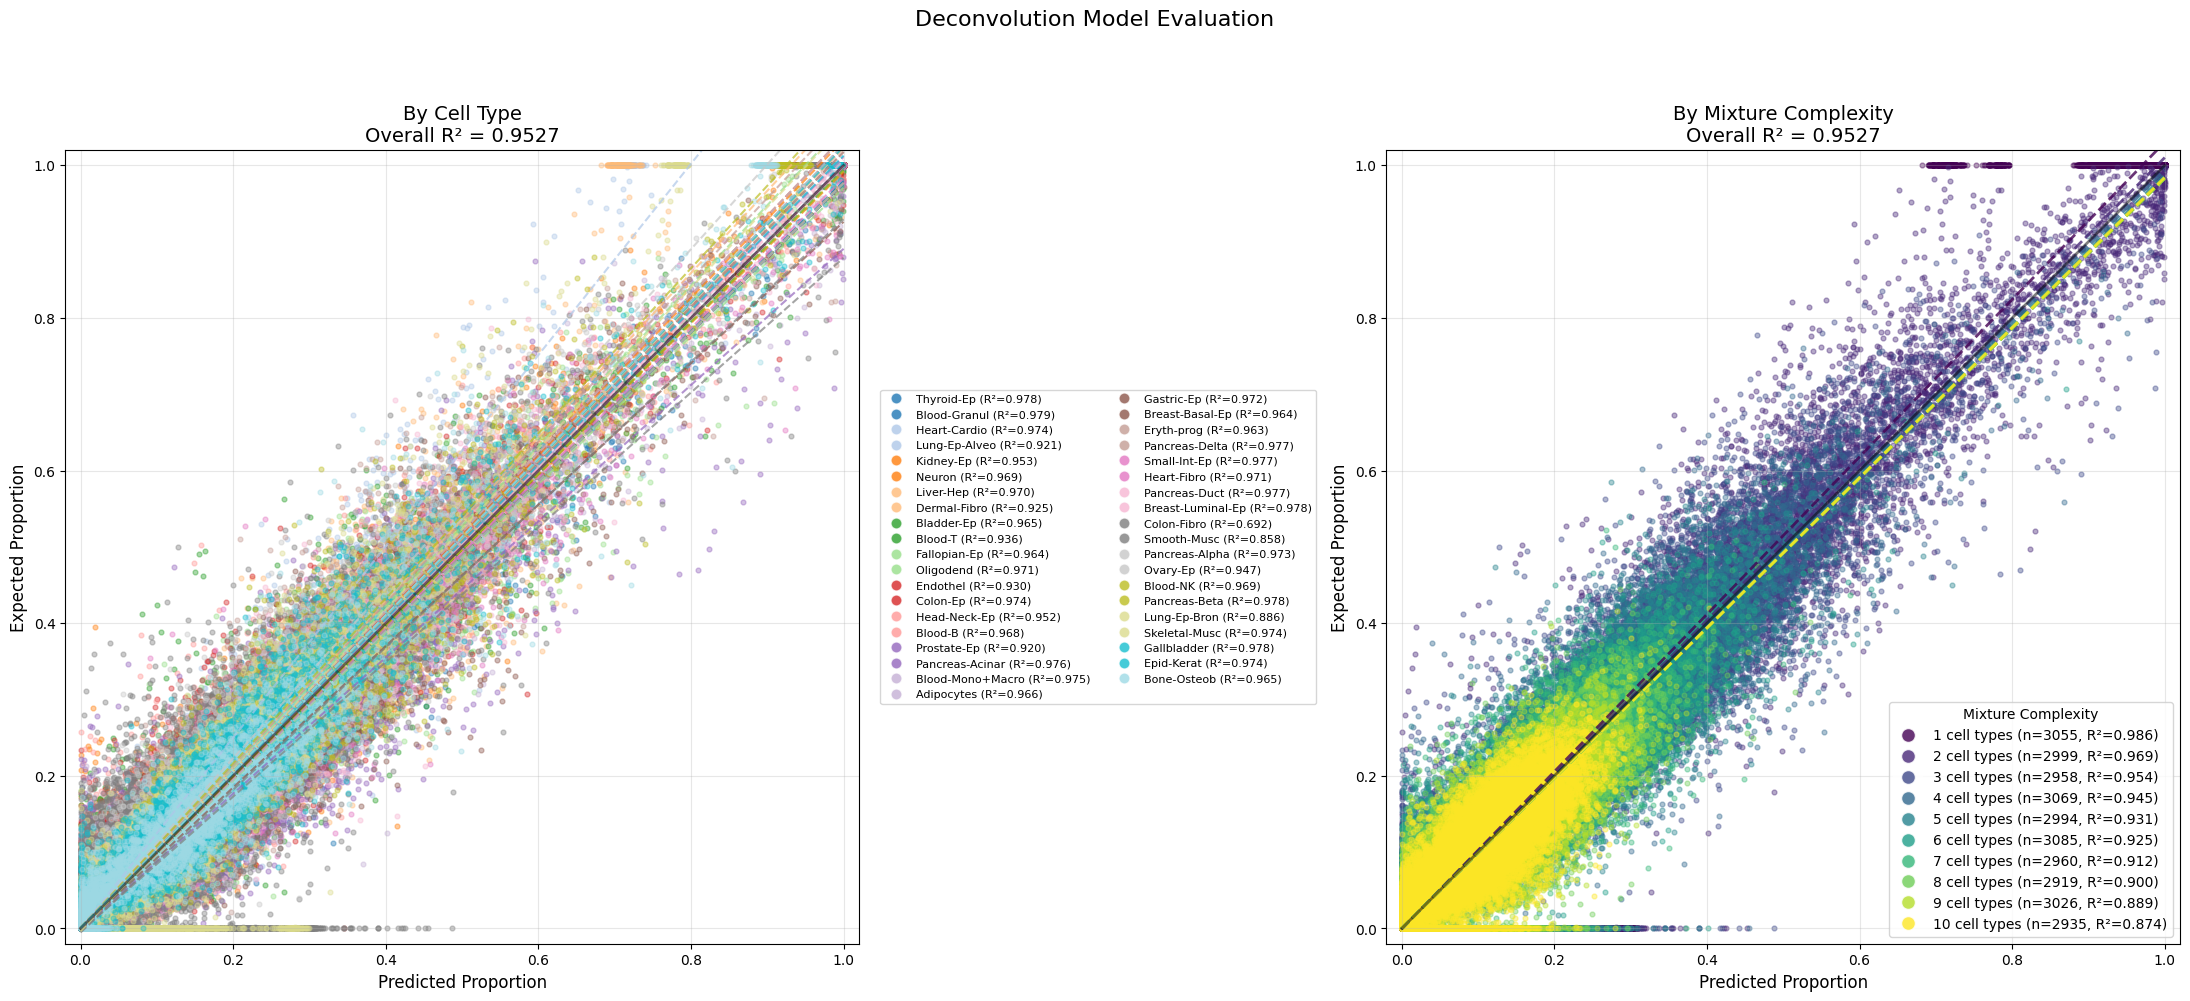

In [149]:
if mode == "training":
    histories = defaultdict(list)
    for model, model_name in model_pairs:

        # Train with early stopping on MAE
        model, history = train_matrix_deconvolver(
            model=model,
            X_train=train_features,
            y_train=train_outputs,
            X_val=valid_features,
            y_val=valid_outputs,
            n_epochs=5000,
            batch_size=500,
            lr=0.5 * 1e-4,
            device="cuda",
            early_stopping_metric="val_mae",  # or 'val_loss', 'val_cosine_sim', etc.
            early_stopping_patience=5000,  # n_epochs == patience --> no early stopping
            early_stopping_min_delta=1e-5,
            scheduler_type=None,
            loss_weights={"mse": 1.0, "kl": 5},
            verbose=1,
            save_path=f"deconvolution_models/{model_name}_best_deconvolver.pt",
        )
        histories[model_name] = history
        # Access history
        print(f"Stopped early: {history.stopped_early}")
        print(f"Best epoch: {history.best_epoch + 1}")
        print(f"Final val MAE: {history.val_mae[history.best_epoch]:.4f}")
elif mode == "inference":
    device = "cuda"
    test_loader = DataLoader(
        TensorDataset(
            torch.FloatTensor(test_features), torch.FloatTensor(test_outputs)
        ),
        batch_size=2000,
    )
    results = defaultdict(tuple)
    for model, model_name in model_pairs:
        model.to(device)
        model.load_state_dict(
            torch.load(
                f"deconvolution_models/{model_name}_best_deconvolver.pt",
                weights_only=True,
            )
        )
        model.eval()

        all_preds = []
        all_targets = []

        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                pred = model(X)

                all_preds.append(pred.cpu())
                all_targets.append(y.cpu())

        # Compute all metrics
        all_preds = torch.cat(all_preds, dim=0)
        all_targets = torch.cat(all_targets, dim=0)
        metrics = compute_deconvolution_metrics(all_preds, all_targets)
        all_targets = all_targets.numpy()
        all_preds = np.round(all_preds.numpy(), 4)

        results[model_name] = (all_targets, all_preds, metrics)
        try:
            fig, all_metrics = plot_deconvolution_results(
                y_true=all_targets,
                y_pred=all_preds,
                labels_dict=labels_dict,
                figsize=(22, 10),
                zero_threshold=0.0001,
                save_path=f"plots/{model_name}_loyfer_test_resuts.png",
                alpha=0.4,
                point_size=12,
            )
        except:
            pass

In [ ]:
# all_targets = np.array([x[0] for x in all_ios])
# all_preds = np.array([x[2] for x in uxm_deconvolution_results])

In [26]:
all_targets = np.array([x[0] for x in all_ios])
all_preds = np.array(xgb_model.predict(test_features))

DECONVOLUTION RESULTS SUMMARY

📊 Overall R²: 0.9487

📋 Per Cell Type R²:
----------------------------------------
  Blood-Granul         │ ███████████████████░ │ 0.9963
  Liver-Hep            │ ███████████████████░ │ 0.9962
  Small-Int-Ep         │ ███████████████████░ │ 0.9938
  Breast-Basal-Ep      │ ███████████████████░ │ 0.9907
  Breast-Luminal-Ep    │ ███████████████████░ │ 0.9906
  Heart-Cardio         │ ███████████████████░ │ 0.9906
  Gastric-Ep           │ ███████████████████░ │ 0.9904
  Colon-Ep             │ ███████████████████░ │ 0.9883
  Thyroid-Ep           │ ███████████████████░ │ 0.9843
  Pancreas-Delta       │ ███████████████████░ │ 0.9829
  Pancreas-Duct        │ ███████████████████░ │ 0.9823
  Pancreas-Alpha       │ ███████████████████░ │ 0.9800
  Neuron               │ ███████████████████░ │ 0.9778
  Blood-Mono+Macro     │ ███████████████████░ │ 0.9680
  Blood-B              │ ███████████████████░ │ 0.9647
  Oligodend            │ ███████████████████░ │ 0.9625
  Fall

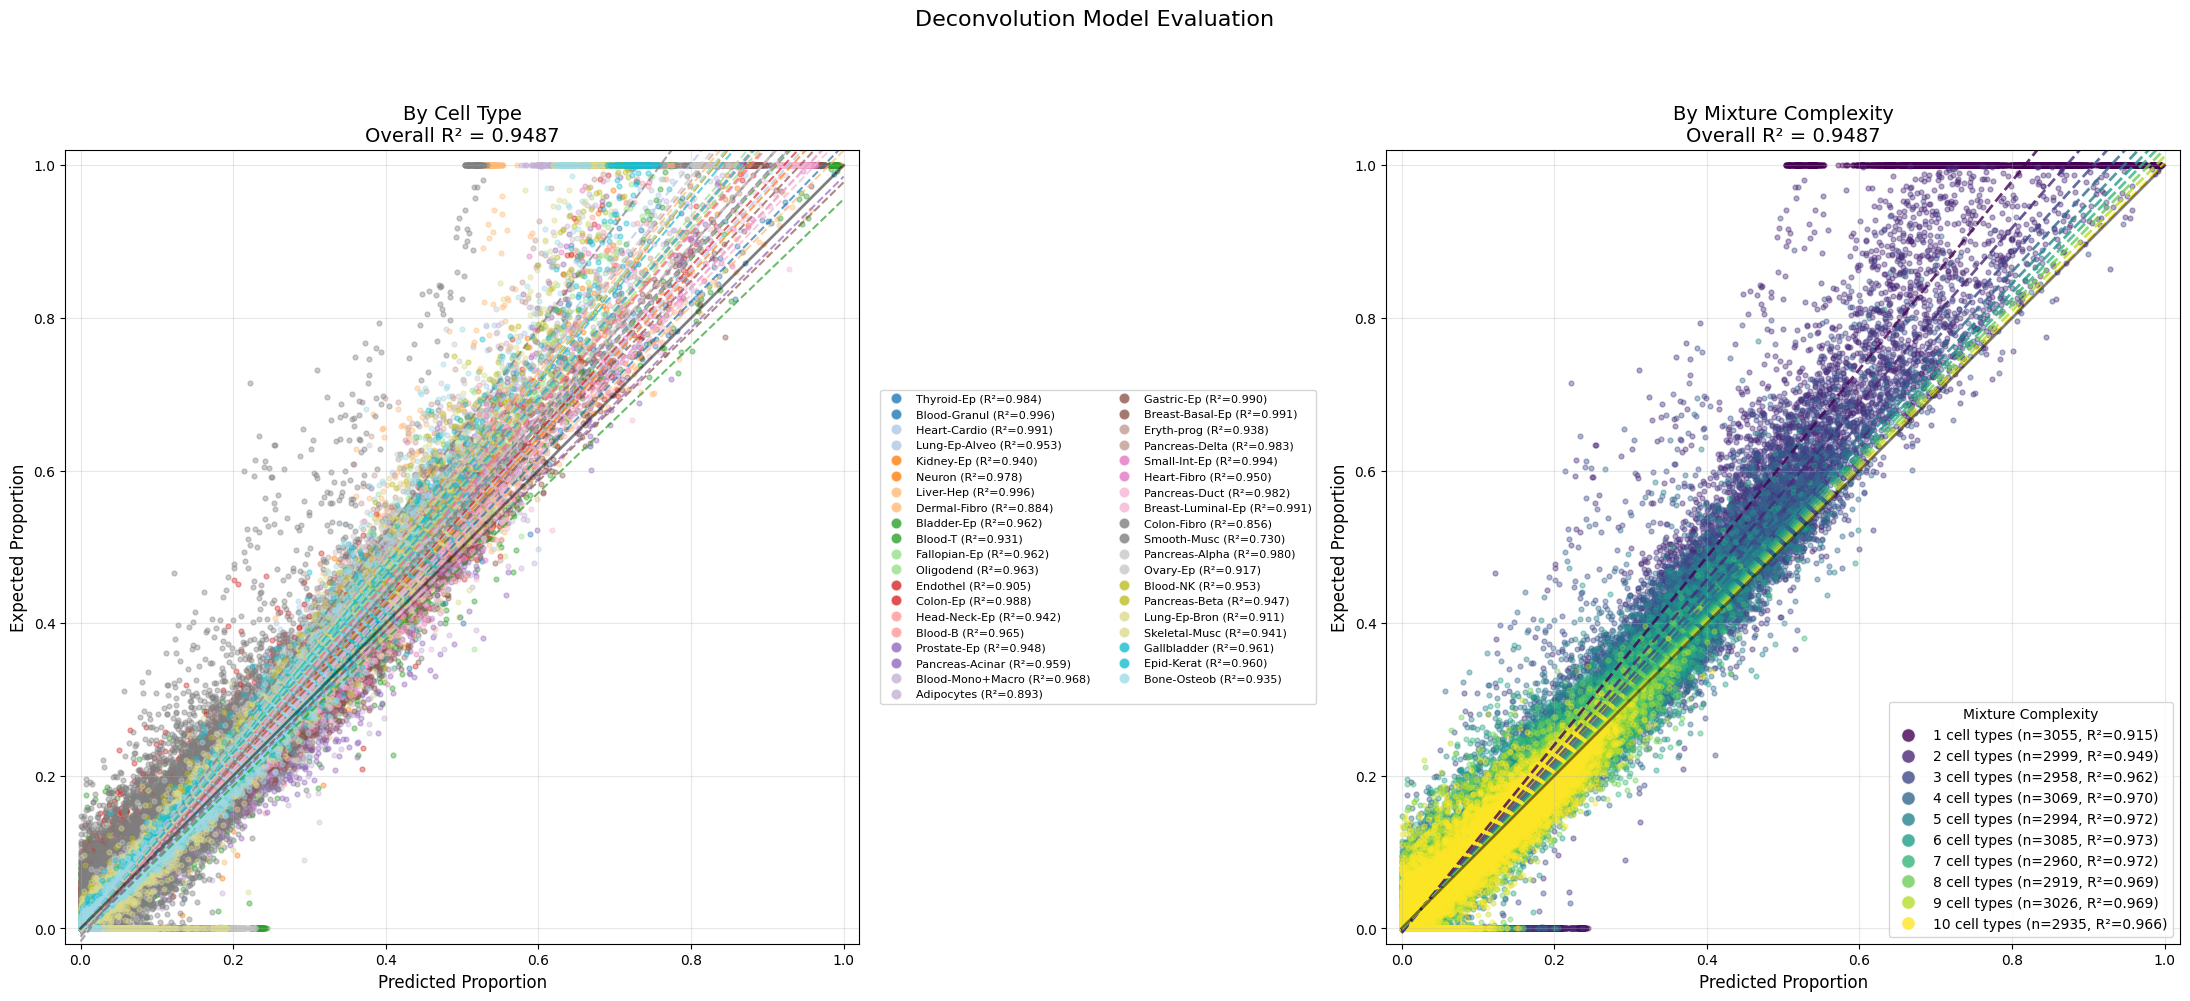

In [27]:
fig, all_metrics = plot_deconvolution_results(
    y_true=all_targets,
    y_pred=all_preds,
    labels_dict=labels_dict,
    figsize=(22, 10),
    zero_threshold=0.0001,
    save_path="deconvolution_results.png",
    alpha=0.4,
    point_size=12,
)

# Print summary
print_deconvolution_metrics_summary(all_metrics)

In [ ]:
# from copy import deepcopy
# histories_with_scheduling = deepcopy(histories)

## Examining DimeLo data


### Preparing DimeLo data

In [2]:
data_path = "/data/dmytro/dimelo_antonella"
dimelo_files = os.listdir(os.path.join(data_path, "DiMeLo"))
dmrs_metadata = pd.read_csv(
    "../../UXM_deconv/supplemental/Atlas.U25.l4.hg38.full.tsv", sep="\t"
)

In [3]:
dimelo_files = [x for x in dimelo_files if ("Sample" in x) and ("bai" not in x)]

In [4]:
wgbs_files = os.listdir(os.path.join(data_path, "BSBolt/WGBS"))
wgbs_files = [x for x in wgbs_files if (x[-3:] == "bam") and ("filtered" not in x)]
wgbs_files = [x for x in wgbs_files if (x[-3:] == "bam")]
wgbs_files = np.sort(wgbs_files)

em_seq_files = os.listdir(os.path.join(data_path, "BSBolt/EMSeq"))
em_seq_files = [x for x in em_seq_files if x[-3:] == "bam"]
em_seq_files = np.sort(em_seq_files)

In [11]:
crc_files = [
    "/data/dmytro/20251216_1438_P2S-01099-A_PBE88013_e323d012/20251216_1438_P2S-01099-A_PBE88013_e323d012/basecalling/CRC001_N01/CRC001_N01.meth_atlas25.bam"
]

In [25]:
chromosomes = [f"chr{i}" for i in range(1, 23, 1)]
chromosomes.extend(["chrX", "chrY"])

# results_df = list()
# for file in dimelo_files:
#     partial_result = process_bam_with_chunking(
#             bam_path=os.path.join(data_path,"DiMeLo", file),
#             chromosomes=[f'chr{i}' for i in range(1,23,1)],
#             n_jobs=4,
#             require_flags=0,
#             data_type='ont',
#             # reference_path = "../../wgbs_tools/references/hg38/hg38.fa.gz",
#         )
#     partial_result["file"] = file
#     partial_result["read_id"] = range(len(partial_result))
#     results_df.append(partial_result)

# results_df = list()
# for file in wgbs_files:
#     partial_result = process_bam_with_chunking(
#             bam_path=os.path.join(data_path,"BSBolt/WGBS", file),
#             chromosomes=chromosomes,
#             n_jobs=12,
#             data_type='wgbs',
#             reference_path = "../../wgbs_tools/references/hg38/hg38.fa.gz",
#             min_cpgs=1
#         )
#     partial_result["file"] = file
#     partial_result["read_id"] = range(len(partial_result))
#     results_df.append(partial_result)

results_df = list()
for file in crc_files:
    partial_result = process_bam_with_chunking(
        bam_path=file,
        chromosomes=[f"chr{i}" for i in range(1, 23, 1)],
        n_jobs=4,
        require_flags=0,
        data_type="ont",
        # reference_path = "../../wgbs_tools/references/hg38/hg38.fa.gz",
    )
    partial_result["file"] = file
    partial_result["read_id"] = range(len(partial_result))
    results_df.append(partial_result)

# results_df = list()
# for file in em_seq_files:
#     partial_result = process_bam_with_chunking(
#             bam_path=os.path.join(data_path,"BSBolt/EMSeq", file),
#             dmr_df=dmrs_metadata,
#             chromosomes=[f'chr{i}' for i in range(1,23,1)],
#             read_chunk_size=150,
#             n_jobs=4,
#             data_type='wgbs',
#             reference_path = "../../wgbs_tools/references/hg38/hg38.fa.gz",
#         )
#     partial_result["file"] = file
#     partial_result["read_id"] = range(len(partial_result))
#     results_df.append(partial_result)

Reading BAM file...
Processing 2887 genomic chunks with 4 workers...
Collected 41388 reads
Merging paired-end reads into fragments...
Read distribution (grouped by ['read_name']):
  Singletons: 39939
  Paired (2 mates): 723
  Multiplets (>2): 1 (will be treated as separate entries)
Merged result: 40665 fragments (from 41388 read entries)


In [26]:
results_df = pd.concat(results_df)

In [29]:
parsed_bam = results_df.sort_values(
    by=["chromosome", "read_start", "read_end"], ascending=True
).reset_index(drop=True)

In [30]:
atlas = atlas.sort_values(by=["chr", "start", "end"], ascending=True).reset_index(
    drop=True
)

In [31]:
from collections import defaultdict
import numpy as np

debug = True
results = []

n_records = len(parsed_bam)

# Build chromosome start index mapping
chrom_start_idx = {}
if n_records > 0:
    current_chrom = parsed_bam.iloc[0]["chromosome"]
    chrom_start_idx[current_chrom] = 0
    for i in range(1, n_records):
        chrom = parsed_bam.iloc[i]["chromosome"]
        if chrom != current_chrom:
            chrom_start_idx[chrom] = i
            current_chrom = chrom

chrom_base_pointer = {}

for _, row in atlas.iterrows():
    name = row["name"]
    chromosome = row["chr"]
    start = row["start"] - 1  # 1-based to 0-based
    end = row["end"]  # EXCLUSIVE

    if chromosome not in chrom_base_pointer:
        chrom_base_pointer[chromosome] = chrom_start_idx.get(chromosome, n_records)

    base_ptr = chrom_base_pointer[chromosome]

    # Advance past records that can't overlap with this or future regions
    while base_ptr < n_records:
        record = parsed_bam.iloc[base_ptr]
        if record["chromosome"] != chromosome:
            break
        if record["read_end"] < start:
            base_ptr += 1
        else:
            break

    chrom_base_pointer[chromosome] = base_ptr

    scan_ptr = base_ptr
    while scan_ptr < n_records:
        record = parsed_bam.iloc[scan_ptr]

        if record["chromosome"] != chromosome:
            break

        if record["read_start"] >= end:
            break

        if record["read_end"] >= start:
            pattern = record["methylation_encoding"]
            seq = record["seq"]

            trimmed_start = max(start, record["read_start"])
            trimmed_end_inclusive = min(end - 1, record["read_end"])

            offset_start = trimmed_start - record["read_start"]
            # offset_end = len(pattern) - (record["read_end"] - trimmed_end_inclusive)+1
            offset_end = trimmed_end_inclusive - trimmed_start + offset_start

            new_pattern = pattern[offset_start:offset_end]
            new_seq = seq[offset_start:offset_end]

            if debug:
                results.append(
                    (
                        chromosome,
                        record["file"],
                        record["read_name"],
                        record["read_start"],
                        record["read_end"],
                        trimmed_start,
                        trimmed_end_inclusive,
                        offset_start,
                        offset_end,
                        pattern,
                        new_pattern,
                        seq,
                        new_seq,
                        name,
                        start,
                        end,
                    )
                )
            else:
                results.append(
                    (
                        chromosome,
                        record["file"],
                        record["read_name"],
                        record["seq"],
                        trimmed_start,
                        trimmed_end_inclusive,
                        new_pattern,
                        new_seq,
                        name,
                        start,
                        end,
                    )
                )

        scan_ptr += 1

# Update column names to reflect actual content
if debug:
    columns = [
        "chr",
        "file",
        "read_name",
        "record_start",
        "record_end",
        "trimmed_start",
        "trimmed_end",
        "offset_start",
        "offset_end",
        "original_pattern",
        "pattern",
        "original_seq",
        "seq",
        "name",
        "region_start",
        "region_end",
    ]
else:
    columns = [
        "chr",
        "file",
        "read_name",
        "trimmed_start",
        "trimmed_end",
        "pattern",
        "seq",
        "name",
        "region_start",
        "region_end",
    ]

results = pd.DataFrame(results, columns=columns)

results["M"] = results["pattern"].apply(lambda x: x.count("1"))
results["U"] = results["pattern"].apply(lambda x: x.count("0"))

# For classification, use only confident calls
results["NCPGS"] = results["M"] + results["U"]
results["M_rate"] = results["M"] / results["NCPGS"].replace(0, np.nan)

is_M = results["M_rate"] >= 0.75
is_U = results["M_rate"] <= 0.25
results["record_M"] = is_M.astype(int)
results["record_U"] = is_U.astype(int)
results["record_X"] = (~is_M & ~is_U).astype(int)

results = pd.merge(results, atlas[["name", "target"]], on="name")
results.rename(columns={"target": "dmr_ctype"}, inplace=True)
labels_dict_reversed = {y: x for (x, y) in labels_dict.items()}
results["dmr_ctype_matched"] = results["dmr_ctype"].apply(
    lambda x: cell_type_match_dict[x] if x in cell_type_match_dict.keys() else x
)
results["dmr_ctype_label"] = results["dmr_ctype_matched"].apply(
    lambda x: int(labels_dict_reversed[x]) if x in labels_dict_reversed.keys() else None
)
results.dropna(subset=["dmr_ctype_label"], inplace=True)
results["dmr_ctype_label"] = results["dmr_ctype_label"].astype(int)

results["pattern_len"] = results["pattern"].apply(len)

In [32]:
assert not np.sum(
    results["pattern_len"] > results["region_end"] - results["region_start"]
), "The resulting sequnces are longer than the regions - this is not right!"

In [33]:
correct_dmrs = set(atlas["name"])

In [34]:
atlas_names = set(atlas["name"].unique())
your_names = set(results["name"].unique())
missing_in_atlas = your_names - atlas_names  # Should be empty
missing_in_yours = atlas_names - your_names  # These are "missing markers"
print(f"Markers in atlas but not in your data: {len(missing_in_yours)}")

Markers in atlas but not in your data: 38


In [35]:
results_agg = (
    results[results["NCPGS"] > 3]
    .groupby(["file", "name"])
    .aggregate({"record_M": "sum", "record_U": "sum", "record_X": "sum"})
    .reset_index()
)
results_agg["count"] = (
    results_agg["record_M"] + results_agg["record_U"] + results_agg["record_X"]
)
results_agg["sf"] = results_agg["record_U"] / results_agg["count"]

In [36]:
results_agg["direction"] = "U"

In [37]:
ref_cells = [x for x in ref_cells if x != "Megakaryocytes"]

In [38]:
uxm_res_dict = defaultdict(dict)
for sample_name in results_df["file"].unique():
    test_example = deepcopy(results_agg[results_agg["file"] == sample_name])
    sf = deepcopy(test_example[["name", "direction"]])
    sf[sample_name] = test_example["sf"]
    counts = test_example[["name", "direction", "count"]]
    counts.columns = ["name", "direction", sample_name]
    uxm_deconv_results = uxm_deconvolution(
        atlas, ref_cells, sf, counts, sample_names=[sample_name]
    )[0]
    uxm_deconv_results = {
        x: np.round(y, 4) for (x, y) in zip(ref_cells, uxm_deconv_results)
    }
    uxm_res_dict[sample_name] = uxm_deconv_results

In [ ]:
with open("crc_ont_parsed_with_uxm_results.pkl", "wb") as f:
    pickle.dump((results, uxm_res_dict), f)

In [ ]:
# with open("wbbs_bsbolt_parsed_with_uxm_results.pkl", "rb") as f:
#     results, uxm_res_dict = pickle.load(f)

In [134]:
results["pattern_len"].value_counts()

pattern_len
151    7913
149    4681
150    4564
147    2854
148    2784
       ... 
376       1
365       1
390       1
387       1
384       1
Name: count, Length: 382, dtype: int64

In [183]:
uxm_console_results = pd.read_csv(
    "/home/luna.kuleuven.be/u0169940/Repos/UXM_deconv/hg38_bsbolt_wgbs_uxm_results.csv",
    sep=",",
)

In [ ]:
for sample_name in uxm_console_results.columns[1:]:
    total_residuals = 0
    uxm_deconv_results = uxm_res_dict[str(sample_name) + ".bam"]
    print(sample_name)
    for x, y in uxm_deconv_results.items():
        if x not in uxm_console_results["CellType"].values:
            continue
        expected = uxm_console_results[uxm_console_results["CellType"] == x][
            sample_name
        ].values[0]
        obtained = uxm_deconv_results[x]
        total_residuals += abs(expected - obtained)
        print(f"{x}: Expected {expected:.1%}, Got: {obtained:.1%}")
    print(f"Total Residuals: {total_residuals:.1%}")
    print("_" * 80)

In [ ]:
# import pickle
# with open("bsbolt_wgbs_processed_reads.pkl", "wb") as f:
#     pickle.dump(results, f)

### Making Predictions

In [35]:
results.rename(columns={"seq": "input_ids", "pattern": "methylation_ids"}, inplace=True)

In [ ]:
# min_len = 130
# results_df = results_df[results_df["input_ids"].apply(len)>=min_len] # filtering shorter reads for a moment

In [11]:
def prepare_methylbert_list_inference(results_df, dmr_label_column, seq_length=150):
    data = results_df
    # data = data.merge(dmrs, on=["dmr_label"])
    data_list = [
        ["dna_seq", "methyl_seq", "dmr_ctype", "dmr_label", "ctype", "original_label"]
    ]
    for i, row in data.iterrows():
        dna = generate_kmer_str_with_overlap(row["input_ids"][: (seq_length + 2)])
        methyl = row["methylation_ids"][1:-1][:seq_length]
        if not len(dna) or not len(methyl):
            # print(row["input_ids"])
            # print(row["read_name"])
            continue
        label = 39  # Setting rejection label as real label is unknown
        o_label = 39  # Setting rejection label as real label is unknown
        dmr_label = row[dmr_label_column]
        dmr_ctype = row["dmr_ctype_label"]
        data_list.append([dna, methyl, dmr_ctype, dmr_label, label, o_label])
    return data_list

In [37]:
dmr_label_column = "dmr_ctype_label"
seq_length = 150

In [ ]:
# results_for_methylbert = results[results["pattern_len"]>=3]

In [38]:
results.rename(
    columns={"seq": "input_ids", "methylation_encoding": "methylation_ids"},
    inplace=True,
)

In [39]:
results_for_methylbert = results[results["pattern_len"] >= 3]

In [40]:
out_of_bag_test = prepare_methylbert_list_inference(
    results_for_methylbert, dmr_label_column=dmr_label_column, seq_length=seq_length
)
out_of_bag_dataset = MethylBertFinetuneDataset(
    data_source=out_of_bag_test,
    vocab=MethylVocab(k=3),
    seq_len=seq_length,
    lazy_tokenization=True,
)

Building Vocab
Total number of sequences: 394839
Using lazy tokenization (on-the-fly processing)


In [41]:
print(len(out_of_bag_dataset), len(results_for_methylbert))

394839 394839


In [42]:
len(out_of_bag_dataset) == len(results_for_methylbert)

True

In [43]:
out_of_bag_predicitons = model_instance.predict(out_of_bag_dataset, batch_size=2200)

/home/luna.kuleuven.be/u0169940/Repos/methyldl/methyldl/modelling/methylbert.py:581: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


OUTPUT DIR IS: tmp_trainer


We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (0) is identical to the `bos_token_id` (0), `eos_token_id` (None), or the `sep_token_id` (None), and your input is not padded.


In [44]:
out_of_bag_predicitons_pd = pd.DataFrame(
    out_of_bag_predicitons[0], columns=["prediction_" + str(x) for x in range(40)]
)
results_for_methylbert = pd.concat(
    [results_for_methylbert.reset_index(), out_of_bag_predicitons_pd.reset_index()],
    axis=1,
)

In [45]:
results_for_methylbert.rename(
    columns={
        "methylated_cpgs": "methylated_CpGs",
        "unmethylated_cpgs": "unmethylated_CpGs",
        "methylation_rate": "methylation_level",
    },
    inplace=True,
)

In [46]:
with open(
    "../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_4_minlen_10/bsbolt_wgbs_results.pkl",
    "wb",
) as f:
    pickle.dump(results_for_methylbert, f)

In [ ]:
# with open("../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_3_minlen_10/bsbolt_wgbs_results.pkl", "rb") as f:
#     results_for_methylbert = pickle.load(f)

In [47]:
results_for_methylbert.dropna(inplace=True)

In [48]:
results_for_methylbert["file"].unique()

array([np.str_('AS-136076.rmdup.bam'), np.str_('AS-136075.rmdup.bam'),
       np.str_('AS-136078.rmdup.bam'), np.str_('AS-136077.rmdup.bam')],
      dtype=object)

In [49]:
results_for_methylbert.rename(columns={"M_rate": "methylation_level"}, inplace=True)

In [50]:
def sample_bulk(total_samples, data):
    res = defaultdict(lambda: pd.DataFrame)
    grouped = data.groupby(["file", "dmr_ctype_label"], sort=False)
    for file in [str(x) for x in data["file"].unique()]:
        sub = []
        for dmr_ctype_label in range(39):
            try:
                group = grouped.get_group((file, dmr_ctype_label))
            except:
                print(
                    f"{(file,dmr_ctype_label)} is absent from the data and will be not included into samples"
                )
            sub.append(group.sample(int(total_samples / 39), replace=True))
        sub = pd.concat(sub)
        # sub = data[data["file"]==file]
        res[file] = aggregate_predictions_by_dmr(
            sub, group_cols=["dmr_ctype"], weight_col="NCPGS"
        )
    return res

### Deriving Proportions

In [51]:
labels_reversed_pd = pd.DataFrame(labels_dict_reversed, index=[0]).T.reset_index()
labels_reversed_pd.columns = ["dmr_ctype", "dmr_ctype_label"]

In [52]:
out_of_bag_deconv_inputs = sample_bulk(
    300_000,
    results_for_methylbert[
        (results_for_methylbert["NCPGS"] >= 4)
        & (results_for_methylbert["pattern_len"] >= 0)
    ],
)

In [91]:
# for key in out_of_bag_deconv_inputs.keys():
#     out_of_bag_deconv_inputs[key] = pd.merge(labels_reversed_pd, out_of_bag_deconv_inputs[key], how="left").fillna(0)

In [53]:
deconv_results = defaultdict(lambda: defaultdict(np.array))
for key in out_of_bag_deconv_inputs.keys():
    X = np.array(
        out_of_bag_deconv_inputs[key][[f"prediction_{i}_wavg" for i in range(40)]]
    )
    deconv_preds = xgb_model.predict(X)
    deconv_preds = np.round(deconv_preds, 4)
    deconv_results["XGB"][key] = deconv_preds

In [55]:
# device = "cuda"
# deconv_results = defaultdict(lambda: defaultdict(np.array))
# for key in out_of_bag_deconv_inputs.keys():
#     X = torch.FloatTensor(np.array(out_of_bag_deconv_inputs[key][[f"prediction_{i}_wavg" for i in range(40)]])).to("cuda")
#     X = torch.unsqueeze(X,0)
#     for model, model_name in zip([diagd], ["diagd"]):
#         model.to(device)
#         model.load_state_dict(torch.load(f"deconvolution_models/{model_name}_best_deconvolver.pt", weights_only=True))
#         model.eval()
#         deconv_preds = model(X)
#         deconv_preds = np.round(deconv_preds.to("cpu").detach().numpy(),4)
#         deconv_results[model_name][key] = deconv_preds[0]

In [81]:
eps = 1e-8
for key in deconv_results["XGB"].keys():
    deconv_preds = np.array(deconv_results["XGB"][key])
    uxm_preds = deepcopy(uxm_res_dict[key])
    uxm_preds = np.array([uxm_preds[key] for key in labels_dict.values()])

    target_safe = np.clip(uxm_preds, eps, None)
    pred_safe = np.clip(deconv_preds, eps, None)
    kl = (target_safe * (np.log(target_safe) - np.log(pred_safe))).sum(axis=-1).mean()
    print(kl)

2.805274714006682
2.8908992995221077
1.9176415782424328
2.932514360189427


In [78]:
for model in ["XGB"]:
    # if model =="diagd":
    print(f"Model: {model}")
    print("_" * 80)
    print("_" * 80)
    for key in deconv_results["XGB"].keys():
        deconv_preds = deconv_results[model][key]
        uxm_preds = uxm_res_dict[key]
        uxm_preds = np.array([uxm_preds[key] for key in labels_dict.values()])
        print(key)
        for i in np.where(np.round(deconv_preds, 2) > 0.025)[0]:
            print(f"{labels_dict[int(i)]}: {deconv_preds[i]:.2f} vs {uxm_preds[i]:.2f}")
        print("_" * 80)
        print("\n")

Model: XGB
________________________________________________________________________________
________________________________________________________________________________
AS-136076.rmdup.bam
Thyroid-Ep: 0.03 vs 0.00
Blood-Granul: 0.04 vs 0.03
Liver-Hep: 0.13 vs 0.00
Fallopian-Ep: 0.10 vs 0.00
Oligodend: 0.03 vs 0.01
Colon-Ep: 0.10 vs 0.23
Gastric-Ep: 0.03 vs 0.00
Eryth-prog: 0.10 vs 0.02
Pancreas-Duct: 0.13 vs 0.01
Pancreas-Alpha: 0.06 vs 0.01
Lung-Ep-Bron: 0.04 vs 0.00
Gallbladder: 0.10 vs 0.01
Epid-Kerat: 0.03 vs 0.00
________________________________________________________________________________


AS-136075.rmdup.bam
Thyroid-Ep: 0.03 vs 0.01
Blood-Granul: 0.04 vs 0.01
Heart-Cardio: 0.06 vs 0.00
Kidney-Ep: 0.03 vs 0.01
Liver-Hep: 0.14 vs 0.00
Fallopian-Ep: 0.12 vs 0.00
Oligodend: 0.04 vs 0.01
Colon-Ep: 0.11 vs 0.28
Gastric-Ep: 0.03 vs 0.00
Eryth-prog: 0.10 vs 0.00
Pancreas-Duct: 0.14 vs 0.01
Pancreas-Alpha: 0.07 vs 0.00
Lung-Ep-Bron: 0.04 vs 0.00
__________________________________

In [ ]:
for model in model_names:
    print(f"Model: {model}")
    print("_" * 80)
    print("_" * 80)
    for key in out_of_bag_deconv_inputs.keys():
        deconv_preds = deconv_results[model][key]
        print(key)
        for i in np.where(np.round(deconv_preds, 2) > 0.025)[0]:
            print(f"{labels_dict[int(i)]}: {deconv_preds[i]:.2f}")
        print("_" * 80)
        print("\n")

### Examining UXM results

In [ ]:
uxm_wgbs = pd.read_csv("../../UXM_deconv/hg38_bsbolt_emseq_uxm_results.csv")

In [ ]:
for key in uxm_wgbs.columns[1:]:
    deconv_preds = uxm_wgbs[key].to_numpy()
    print(key)
    print("\n")
    for i in np.where(np.round(deconv_preds, 2) > 0.025)[0]:
        print(f"{uxm_wgbs["CellType"][int(i)]}: {deconv_preds[i]:.2f}")
    print("_" * 80)
    print("\n")

### Visualizing predictions and methylation levels

In [ ]:
plot_methylation_with_predictions(
    results_df[results_df["file"] == list(deconv_results.keys())[0]], figsize=(20, 6)
)

## Examining individual reads

In [ ]:
test_data[test_data["total_methylated_labels"] > 3].head()

In [ ]:
test_data[test_data["read_id"] == 2961948].to_dict(orient="records")